# Modelling Rainfall in Wädenswil

This notebook explores different optimization algorithms for the purpose of modelling rainfall in Wädenswil (CH). The dataset used can be found under the following link:
https://data.geo.admin.ch/ch.meteoschweiz.ogd-smn/wae/ogd-smn_wae_d_historical.csv

---

## PROBLEM STATEMENT

The goal of this project is to predict daily rainfall (`precip_0utc_d`) from meteorological parameters such as air temperature, soil temperature, wind or vapor pressure.

In order to try and minimize the complexity of the optimization problem and investigate the influence of dimension reduction on typical optimization algorithms we consider two optimization problems:

1. **Feature selection**: find a subset of input features that yields good predictive performance  
2. **Parameter optimization**: find model parameters that minimize prediction error for a fixed feature subset

Feature selection is performed using Ant Colony Optimization (ACO).  
Model parameters are optimized using Gradient Descent (GD), Simulated Annealing (SA), and a Genetic Algorithm (GA).

Finally the performance of the fixed feature subset model is compared to a full model that includes all features. 

---

## MATHEMATICAL FORMULATION

For a fixed feature subset $S$, we use a linear regression model

$$
\hat{y}_i = w_0 + \sum_{j \in S} w_j x_{ij}
$$

where:
- $x_{ij}$ is feature $j$ for sample $i$
- $w_j$ are model parameters
- $\hat{y}_i$ is the predicted precipitation

The parameter optimization problem is

$$
\min_{w} \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2
$$

where $y_i$ is the observed precipitation.

The feature selection problem is

$$
\min_{S \subseteq \mathcal{F}} \; \text{MSE}_{val}(S)
$$

where $\mathcal{F}$ is the full feature set and $\text{MSE}_{val}(S)$ is the validation error obtained after fitting the model on subset $S$.

---

## IMPLEMENTATION

Additionally to the base features from the dataset the following metrics were derived:
- Precipitation Lag (1-3): Encodes if there was rainfall in the prior days
- Seasonal Features: Datetime encoded as sine and cosine, year and month

#### List of Features

| Nr. | Feature | Description |
|---:|---|---|
| 1 | `temp2m_mean_d` | Daily mean air temperature at 2 m above ground |
| 2 | `temp2m_max_d` | Daily maximum air temperature at 2 m above ground |
| 3 | `temp2m_min_d` | Daily minimum air temperature at 2 m above ground |
| 4 | `temp5cm_mean_d` | Daily mean near-surface temperature at 5 cm |
| 5 | `temp5cm_max_d` | Daily maximum near-surface temperature at 5 cm |
| 6 | `temp5cm_min_d` | Daily minimum near-surface temperature at 5 cm |
| 7 | `rh2m_mean_d` | Daily mean relative humidity at 2 m above ground |
| 8 | `atm_pressure_d` | Daily mean atmospheric pressure |
| 9 | `sealevel_pressure_d` | Daily mean sealevel pressure |
| 10 | `sunshine_duration_d` | Daily sunshine duration |
| 11 | `global_radiation_d` | Global radiation per day |
| 12 | `vapor_pressure_d` | Daily mean vapor pressure, describing atmospheric moisture content |
| 13 | `wind_ms_mean_d` | Daily wind speed mean in m/s |
| 14 | `gust_ms_max_d` | Max gust speed in m/s |
| 15 | `foehn_idx_d` | Daily foehn index |
| 16 | `wind_dir_mean_d` | Daily wind direction mean |
| 17 | `heating_degree_days_d` | Heating degree days daily |
| 18 | `soil_temp_5cm_mean_d` | Daily mean soil temperature at 5 cm depth |
| 19 | `soil_temp_10cm_mean_d` | Daily mean soil temperature at 10 cm depth |
| 20 | `soil_temp_20cm_mean_d` | Daily mean soil temperature at 20 cm depth |
| 21 | `doy_sin` | Sine-transformed day-of-year feature to encode annual seasonality |
| 22 | `doy_cos` | Cosine-transformed day-of-year feature to encode annual seasonality |
| 23 | `year` | Calendar year |
| 24 | `month` | Calendar month |
| 25 | `precip_lag1` | Precipitation of the previous day |
| 26 | `precip_lag2` | Precipitation two days before |
| 27 | `precip_lag3` | Precipitation three days before |

The implemented pipeline is structured as follows:
#### 1. Feature Selection with ACO 
Each ant constructs a subset of features, which is evaluated using a linear regression model.  
Feature subsets that lead to lower prediction error receive stronger pheromone updates, increasing their probability of being selected in future iterations.


#### 2. Parameter Optimization — GD, SA, GA

For a fixed feature subset, we optimize the model parameters using three different approaches:

- **Gradient Descent (GD):**  
  A deterministic, gradient-based method that efficiently optimizes smooth objective functions.

- **Simulated Annealing (SA):**  
  A stochastic optimization method that explores the search space by occasionally accepting worse solutions to escape local minima.

- **Genetic Algorithm (GA):**  
  A population-based evolutionary algorithm that evolves candidate solutions using selection, crossover, and mutation.


#### 3. Model Evaluation and Comparison

All methods are evaluated on the same dataset using:

- RMSE (Root Mean Squared Error)
- MAE (Mean Absolute Error)
- R² score
- Runtime

The optimized model using only the feature subset proposed by ACO is then compared to a full model that uses all features. Thereby we can further compare the algorithms by the means of dimensionality and redundancy.

---

## Setup Environment with conda

1) Create the conda environment
`conda env create -f environment.yml`

2) Activate it
`conda activate BioInspAlg`

3) (Optional) Update environment after changes
`conda env update -f environment.yml --prune`

4) To register the environment as a jupyter kernel run
`python -m ipykernel install --user --name BioInspAlg --display-name "Python (BioInspAlg)"`

## Imports


In [2]:
import io
import matplotlib.pyplot as plt
import ssl
import urllib.request  
import numpy as np
import pandas as pd
import time

from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression


## Data Import and Preparation

In [3]:
station_url = "https://data.geo.admin.ch/ch.meteoschweiz.ogd-smn/wae/ogd-smn_wae_d_historical.csv"

ctx = ssl.create_default_context()

raw_text = urllib.request.urlopen(station_url, context=ctx).read().decode("utf-8")

try:
    station_df = pd.read_csv(io.StringIO(raw_text), sep=None, engine="python")
except Exception:
    station_df = pd.read_csv(io.StringIO(raw_text), sep=";")

station_df.head()


,station_abbr,reference_timestamp,tre200d0,tre200dx,tre200dn,tre005d0,tre005dx,tre005dn,ure200d0,pva200d0,...,sremaxdv,erefaod0,xcd000d0,dkl010d0,xno000d0,xno012d0,rreetsd0,tso005d0,tso010d0,tso020d0
0,WAE,01.01.1961 00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,WAE,02.01.1961 00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,WAE,03.01.1961 00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,WAE,04.01.1961 00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,WAE,05.01.1961 00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
rename_dict = {
    "tre200d0": "temp2m_mean_d",
    "tre200dx": "temp2m_max_d",
    "tre200dn": "temp2m_min_d",
    "tre005d0": "temp5cm_mean_d",
    "tre005dx": "temp5cm_max_d",
    "tre005dn": "temp5cm_min_d",
    "ure200d0": "rh2m_mean_d",
    "prestad0": "atm_pressure_d",
    "pp0qffd0": "sealevel_pressure_d",
    "sre000d0": "sunshine_duration_d",
    "gre000d0": "global_radiation_d",
    "pva200d0": "vapor_pressure_d",
    "fkl010d0": "wind_ms_mean_d",
    "fkl010d1": "gust_ms_max_d",
    "wcc006d0": "foehn_idx_d",
    "rka150d0": "precip_0utc_d",
    "dkl010d0": "wind_dir_mean_d",
    "xno000d0": "heating_degree_days_d",
    "tso005d0": "soil_temp_5cm_mean_d",
    "tso010d0": "soil_temp_10cm_mean_d",
    "tso020d0": "soil_temp_20cm_mean_d",
}

base_cols = ["station_abbr", "reference_timestamp"]
value_cols = [c for c in rename_dict if c in station_df.columns]

df = station_df[base_cols + value_cols].copy()
df["reference_timestamp"] = pd.to_datetime(df["reference_timestamp"], dayfirst=True, errors="coerce")
df = df.rename(columns=rename_dict)

# Keep only rows with valid station/date/target for now
df = df.dropna(subset=["station_abbr", "reference_timestamp", "precip_0utc_d"]).reset_index(drop=True)

# Sort first
df = df.sort_values(["station_abbr", "reference_timestamp"]).reset_index(drop=True)
df.head()

,station_abbr,reference_timestamp,temp2m_mean_d,temp2m_max_d,temp2m_min_d,temp5cm_mean_d,temp5cm_max_d,temp5cm_min_d,rh2m_mean_d,atm_pressure_d,...,vapor_pressure_d,wind_ms_mean_d,gust_ms_max_d,foehn_idx_d,precip_0utc_d,wind_dir_mean_d,heating_degree_days_d,soil_temp_5cm_mean_d,soil_temp_10cm_mean_d,soil_temp_20cm_mean_d
0,WAE,1981-01-01,2.7,5.2,-3.2,1.4,4.6,-6.0,66.4,NaN,...,4.9,4.9,14.0,NaN,1.2,259.0,17.3,0.2,0.5,1.0
1,WAE,1981-01-02,1.5,3.5,0.2,1.0,2.8,-0.2,80.5,NaN,...,5.5,3.3,13.3,NaN,4.4,252.0,18.5,0.2,0.6,1.0
2,WAE,1981-01-03,6.2,9.3,2.4,4.9,8.3,0.3,62.8,NaN,...,5.9,6.0,22.6,NaN,11.2,261.0,13.8,1.0,0.9,1.1
3,WAE,1981-01-04,2.6,6.2,-2.2,1.8,4.9,-2.0,84.1,NaN,...,6.3,3.9,21.4,NaN,26.4,260.0,17.4,1.8,1.8,1.8
4,WAE,1981-01-05,-0.5,1.3,-1.8,-0.8,1.8,-2.3,73.2,NaN,...,4.3,6.7,16.8,NaN,2.0,250.0,20.5,1.0,1.2,1.5


In [5]:
TARGET_COL = "precip_0utc_d"
STATION_COL = "station_abbr" 
DATE_COL = "reference_timestamp"

TEST_SIZE = 0.15
VAL_SIZE  = 0.15
RANDOM_SEED = 42

# Time aware split
TIME_AWARE_SPLIT = True if DATE_COL else False

In [6]:
def add_time_features(df: pd.DataFrame, date_col: str) -> pd.DataFrame:
    """
    Creates numeric time features in the form of sine and cosine encodings.
    Seasonality is encoded as a cycle.
    """
    d = df.copy()
    d[date_col] = pd.to_datetime(d[date_col])

    # day-of-year cyclic encoding
    doy = d[date_col].dt.dayofyear.astype(int)
    d["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
    d["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)

    # year and month are kept as numeric features additionally
    d["year"] = d[date_col].dt.year.astype(int)
    d["month"] = d[date_col].dt.month.astype(int)

    return d



In [7]:
def enforce_daily_grid_and_add_target_lags(
    df: pd.DataFrame,
    station_col: str,
    date_col: str,
    target_col: str,
    lags: List[int]
) -> pd.DataFrame:
    """
    Reindex each station to a complete daily calendar so that shift(L)
    means exactly L calendar days earlier.
    """
    out_parts = []

    for station, g in df.groupby(station_col, sort=False):
        g = g.sort_values(date_col).copy()

        full_dates = pd.date_range(
            start=g[date_col].min(),
            end=g[date_col].max(),
            freq="D"
        )

        g = g.set_index(date_col).reindex(full_dates).rename_axis(date_col).reset_index()
        g[station_col] = station

        for L in lags:
            g[f"precip_lag{L}"] = g[target_col].shift(L)

        out_parts.append(g)

    out = pd.concat(out_parts, ignore_index=True)
    out = out.sort_values([station_col, date_col]).reset_index(drop=True)
    return out

In [8]:
if DATE_COL is not None:
    df = add_time_features(df, DATE_COL)

# Add true calendar-day precipitation lags
LAGS = [1, 2, 3]
df = enforce_daily_grid_and_add_target_lags(
    df=df,
    station_col=STATION_COL,
    date_col=DATE_COL,
    target_col=TARGET_COL,
    lags=LAGS
)

excluded = {TARGET_COL, STATION_COL}
if DATE_COL is not None:
    excluded.add(DATE_COL)

CANDIDATE_FEATURES = [c for c in df.columns if c not in excluded]
CANDIDATE_FEATURES = [c for c in CANDIDATE_FEATURES if pd.api.types.is_numeric_dtype(df[c])]

print("Num candidate features:", len(CANDIDATE_FEATURES))
print(CANDIDATE_FEATURES)

Num candidate features: 27
['temp2m_mean_d', 'temp2m_max_d', 'temp2m_min_d', 'temp5cm_mean_d', 'temp5cm_max_d', 'temp5cm_min_d', 'rh2m_mean_d', 'atm_pressure_d', 'sealevel_pressure_d', 'sunshine_duration_d', 'global_radiation_d', 'vapor_pressure_d', 'wind_ms_mean_d', 'gust_ms_max_d', 'foehn_idx_d', 'wind_dir_mean_d', 'heating_degree_days_d', 'soil_temp_5cm_mean_d', 'soil_temp_10cm_mean_d', 'soil_temp_20cm_mean_d', 'doy_sin', 'doy_cos', 'year', 'month', 'precip_lag1', 'precip_lag2', 'precip_lag3']


In [9]:
# Sanity checks

missing = [c for c in [TARGET_COL, STATION_COL] if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns in df: {missing}")

if DATE_COL is not None and DATE_COL not in df.columns:
    raise ValueError(f"DATE_COL='{DATE_COL}' not found in df. Set DATE_COL=None or correct the name.")

if len(CANDIDATE_FEATURES) == 0:
    raise ValueError("No numeric candidate features found after exclusions.")

df[[TARGET_COL] + CANDIDATE_FEATURES[:10]].head()

,precip_0utc_d,temp2m_mean_d,temp2m_max_d,temp2m_min_d,temp5cm_mean_d,temp5cm_max_d,temp5cm_min_d,rh2m_mean_d,atm_pressure_d,sealevel_pressure_d,sunshine_duration_d
0,1.2,2.7,5.2,-3.2,1.4,4.6,-6.0,66.4,NaN,NaN,1.0
1,4.4,1.5,3.5,0.2,1.0,2.8,-0.2,80.5,NaN,NaN,0.0
2,11.2,6.2,9.3,2.4,4.9,8.3,0.3,62.8,NaN,NaN,0.0
3,26.4,2.6,6.2,-2.2,1.8,4.9,-2.0,84.1,NaN,NaN,4.0
4,2.0,-0.5,1.3,-1.8,-0.8,1.8,-2.3,73.2,NaN,NaN,50.0


## INSPECT DATA

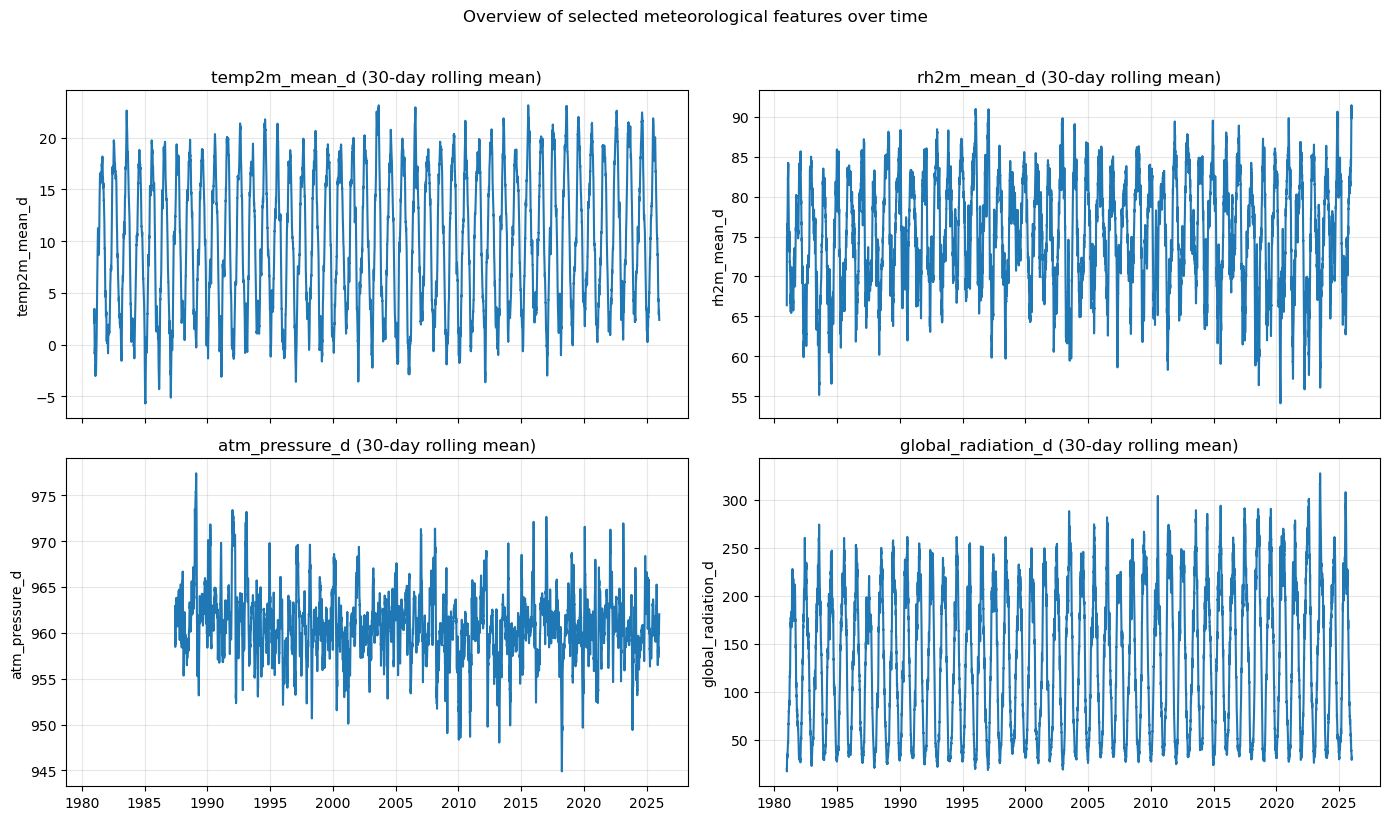

In [10]:
# Plot some features for overview
plot_features = [
    "temp2m_mean_d",
    "rh2m_mean_d",
    "atm_pressure_d",
    "global_radiation_d",
]

plot_df = df[[DATE_COL] + plot_features].copy().sort_values(DATE_COL)
plot_df[DATE_COL] = pd.to_datetime(plot_df[DATE_COL])

roll_days = 30

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes = axes.ravel()

for ax, feat in zip(axes, plot_features):
    ax.plot(
        plot_df[DATE_COL],
        plot_df[feat].rolling(roll_days, min_periods=1).mean()
    )
    ax.set_title(f"{feat} ({roll_days}-day rolling mean)")
    ax.set_ylabel(feat)
    ax.grid(alpha=0.3)

plt.suptitle("Overview of selected meteorological features over time", y=1.02)
plt.tight_layout()
plt.show()

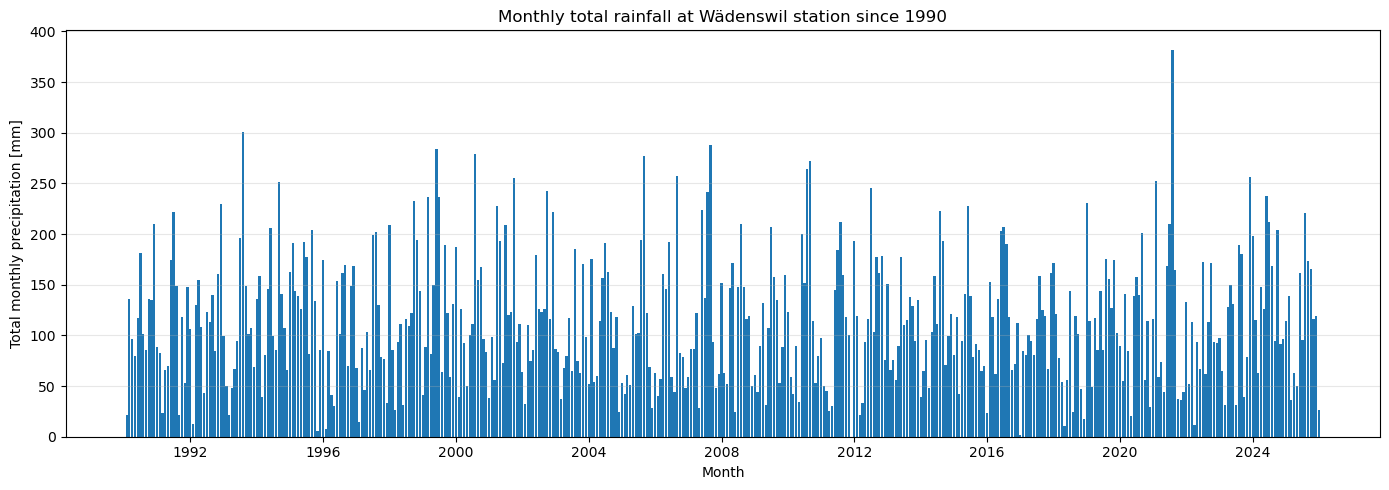

In [11]:
rain_monthly = df.copy()
rain_monthly[DATE_COL] = pd.to_datetime(rain_monthly[DATE_COL])

rain_monthly = rain_monthly[rain_monthly[DATE_COL] >= "1990-01-01"]

monthly_rain = (
    rain_monthly
    .set_index(DATE_COL)[TARGET_COL]
    .resample("ME")
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 5))
plt.bar(monthly_rain[DATE_COL], monthly_rain[TARGET_COL], width=25)
plt.xlabel("Month")
plt.ylabel("Total monthly precipitation [mm]")
plt.title("Monthly total rainfall at Wädenswil station since 1990")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


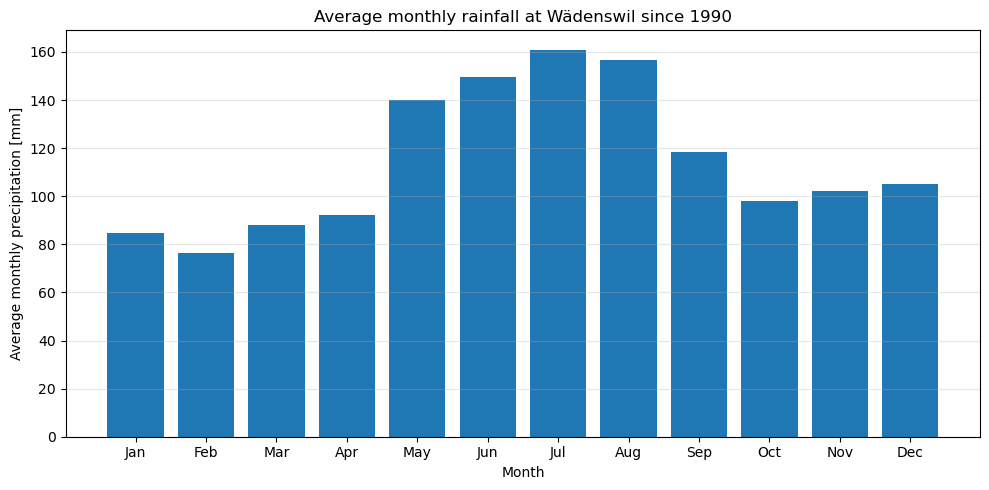

In [12]:
rain_monthly = df.copy()
rain_monthly[DATE_COL] = pd.to_datetime(rain_monthly[DATE_COL])
rain_monthly = rain_monthly[rain_monthly[DATE_COL] >= "1990-01-01"]

monthly_totals = (
    rain_monthly
    .set_index(DATE_COL)[TARGET_COL]
    .resample("ME")
    .sum()
    .reset_index()
)

monthly_totals["month"] = monthly_totals[DATE_COL].dt.month

avg_monthly_rain = (
    monthly_totals
    .groupby("month")[TARGET_COL]
    .mean()
    .reset_index()
)

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

plt.figure(figsize=(10, 5))
plt.bar(avg_monthly_rain["month"], avg_monthly_rain[TARGET_COL])
plt.xticks(range(1, 13), month_labels)
plt.xlabel("Month")
plt.ylabel("Average monthly precipitation [mm]")
plt.title("Average monthly rainfall at Wädenswil since 1990")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [13]:
# Inspect how much data is actually used and how much is dropped

n_raw = len(station_df)

df_selected = station_df[base_cols + value_cols].copy()
df_selected[DATE_COL] = pd.to_datetime(df_selected[DATE_COL], dayfirst=True, errors="coerce")
df_selected = df_selected.rename(columns=rename_dict)
n_selected = len(df_selected)

df_base = df_selected.dropna(subset=[STATION_COL, DATE_COL, TARGET_COL]).reset_index(drop=True)
df_base = df_base.sort_values([STATION_COL, DATE_COL]).reset_index(drop=True)
n_after_base_filter = len(df_base)

first_raw_ts = df_base[DATE_COL].min()
last_raw_ts = df_base[DATE_COL].max()
raw_span_days = (last_raw_ts - first_raw_ts).days

df_pipeline = df_base.copy()
if DATE_COL is not None:
    df_pipeline = add_time_features(df_pipeline, DATE_COL)

LAGS = [1, 2, 3]
df_pipeline = enforce_daily_grid_and_add_target_lags(
    df=df_pipeline,
    station_col=STATION_COL,
    date_col=DATE_COL,
    target_col=TARGET_COL,
    lags=LAGS
)
n_after_daily_grid = len(df_pipeline)

first_grid_ts = df_pipeline[DATE_COL].min()
last_grid_ts = df_pipeline[DATE_COL].max()
grid_span_days = (last_grid_ts - first_grid_ts).days

excluded_tmp = {TARGET_COL, STATION_COL}
if DATE_COL is not None:
    excluded_tmp.add(DATE_COL)

candidate_features_tmp = [c for c in df_pipeline.columns if c not in excluded_tmp]
candidate_features_tmp = [
    c for c in candidate_features_tmp
    if pd.api.types.is_numeric_dtype(df_pipeline[c])
]

used_cols = candidate_features_tmp + [TARGET_COL, STATION_COL, DATE_COL]
df_final_used = df_pipeline.dropna(
    subset=[c for c in used_cols if c is not None]
).reset_index(drop=True)

n_final_used = len(df_final_used)

first_used_ts = df_final_used[DATE_COL].min()
last_used_ts = df_final_used[DATE_COL].max()
used_span_days = (last_used_ts - first_used_ts).days

n_train = int(np.floor(0.60 * n_final_used))
n_sel   = int(np.floor(0.15 * n_final_used))
n_tune  = int(np.floor(0.10 * n_final_used))
n_test  = n_final_used - n_train - n_sel - n_tune

usage_summary = pd.DataFrame({
    "stage": [
        "Raw downloaded rows",
        "After selecting/renaming columns",
        "After base filter (valid station/date/target)",
        "After enforcing full daily grid",
        "Final rows usable for modeling",
        "Train rows",
        "Selection rows",
        "Tuning rows",
        "Test rows",
    ],
    "n_rows": [
        n_raw,
        n_selected,
        n_after_base_filter,
        n_after_daily_grid,
        n_final_used,
        n_train,
        n_sel,
        n_tune,
        n_test,
    ]
})

usage_summary["pct_of_raw"] = 100 * usage_summary["n_rows"] / n_raw

timeline_summary = pd.DataFrame({
    "timeline_stage": [
        "Observed data before daily grid",
        "Daily grid timeline",
        "Final usable modeling rows",
    ],
    "first_timestamp": [
        first_raw_ts,
        first_grid_ts,
        first_used_ts,
    ],
    "last_timestamp": [
        last_raw_ts,
        last_grid_ts,
        last_used_ts,
    ],
    "span_days": [
        raw_span_days,
        grid_span_days,
        used_span_days,
    ],
})

print("Usage summary:")
display(usage_summary)

print("\nTimeline summary:")
display(timeline_summary)

Usage summary:


,stage,n_rows,pct_of_raw
0,Raw downloaded rows,23741,100.000000
1,After selecting/renaming columns,23741,100.000000
2,After base filter (valid station/date/target),16415,69.141991
3,After enforcing full daily grid,16436,69.230445
4,Final rows usable for modeling,4924,20.740491
5,Train rows,2954,12.442610
6,Selection rows,738,3.108546
7,Tuning rows,492,2.072364
8,Test rows,740,3.116971



Timeline summary:


,timeline_stage,first_timestamp,last_timestamp,span_days
0,Observed data before daily grid,1981-01-01,2025-12-31,16435
1,Daily grid timeline,1981-01-01,2025-12-31,16435
2,Final usable modeling rows,2012-03-05,2025-12-31,5049


The original dataset contains 23'741 rows (span of 16'435 days). After constructing lag features, enforcing daily grid and removing rows with missing values, a total of 4'924 rows (span of 4'924 days) remains for modeling. This is due to the fact, that some metrics were not measured at the start of the dataset, but got added later on.

## Split Preparation 

We create a 4-way split for training, validation of the subset selection with ACO, tuning validation for each model and testing.

In [14]:
def make_time_splits_4way(
    df: pd.DataFrame,
    target_col: str,
    feature_cols: List[str],
    station_col: str,
    date_col: str,
    train_frac: float = 0.60,
    sel_frac: float = 0.15,
    tune_frac: float = 0.10,
    test_frac: float = 0.15,
):
    assert abs(train_frac + sel_frac + tune_frac + test_frac - 1.0) < 1e-9

    d = df.copy()
    used_cols = feature_cols + [target_col, station_col, date_col]
    d = d.dropna(subset=[c for c in used_cols if c is not None]).reset_index(drop=True)
    d[date_col] = pd.to_datetime(d[date_col])
    d = d.sort_values([station_col, date_col]).reset_index(drop=True)

    n = len(d)
    n_train = int(np.floor(train_frac * n))
    n_sel   = int(np.floor(sel_frac * n))
    n_tune  = int(np.floor(tune_frac * n))
    n_test  = n - n_train - n_sel - n_tune

    train_df = d.iloc[:n_train]
    sel_df   = d.iloc[n_train:n_train + n_sel]
    tune_df  = d.iloc[n_train + n_sel:n_train + n_sel + n_tune]
    test_df  = d.iloc[n_train + n_sel + n_tune:]

    X_train = train_df[feature_cols].to_numpy(dtype=float)
    y_train = train_df[target_col].to_numpy(dtype=float)

    X_sel = sel_df[feature_cols].to_numpy(dtype=float)
    y_sel = sel_df[target_col].to_numpy(dtype=float)

    X_tune = tune_df[feature_cols].to_numpy(dtype=float)
    y_tune = tune_df[target_col].to_numpy(dtype=float)

    X_test = test_df[feature_cols].to_numpy(dtype=float)
    y_test = test_df[target_col].to_numpy(dtype=float)

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_sel_s   = scaler.transform(X_sel)
    X_tune_s  = scaler.transform(X_tune)
    X_test_s  = scaler.transform(X_test)

    return (X_train_s, y_train), (X_sel_s, y_sel), (X_tune_s, y_tune), (X_test_s, y_test), scaler


(X_train, y_train), (X_sel, y_sel), (X_tune, y_tune), (X_test, y_test), scaler = make_time_splits_4way(
    df=df,
    target_col=TARGET_COL,
    feature_cols=CANDIDATE_FEATURES,
    station_col=STATION_COL,
    date_col=DATE_COL,
    train_frac=0.60,
    sel_frac=0.15,
    tune_frac=0.10,
    test_frac=0.15,
)

print("Shapes:", X_train.shape, X_sel.shape, X_tune.shape, X_test.shape)


def transform_target(y: np.ndarray) -> np.ndarray:
    return np.log1p(y)


def inverse_target(y: np.ndarray) -> np.ndarray:
    return np.expm1(y)


y_train_model = transform_target(y_train)
y_sel_model = transform_target(y_sel)
y_tune_model = transform_target(y_tune)
y_test_model = transform_target(y_test)


Shapes: (2954, 27) (738, 27) (492, 27) (740, 27)


## Define Helper Functions

In [15]:
def add_bias(X: np.ndarray) -> np.ndarray:
    return np.hstack([np.ones((X.shape[0], 1)), X])

def prediction_to_original_scale(pred_model: np.ndarray) -> np.ndarray:
    if not np.all(np.isfinite(pred_model)):
        return np.full_like(pred_model, np.inf, dtype=float)
    pred = inverse_target(pred_model)
    pred = np.maximum(0.0, pred)
    if not np.all(np.isfinite(pred)):
        return np.full_like(pred_model, np.inf, dtype=float)
    return pred

def safe_rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    if not np.all(np.isfinite(y_pred)):
        return float(np.inf)
    err = y_true - y_pred
    if not np.all(np.isfinite(err)):
        return float(np.inf)
    mse = np.mean(err ** 2)
    if not np.isfinite(mse):
        return float(np.inf)
    return float(np.sqrt(mse))

def safe_mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    if not np.all(np.isfinite(y_pred)):
        return float(np.inf)
    err = np.abs(y_true - y_pred)
    if not np.all(np.isfinite(err)):
        return float(np.inf)
    mae = np.mean(err)
    if not np.isfinite(mae):
        return float(np.inf)
    return float(mae)

def safe_r2(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    if not np.all(np.isfinite(y_pred)):
        return float(-np.inf)
    try:
        score = r2_score(y_true, y_pred)
    except ValueError:
        return float(-np.inf)
    return float(score) if np.isfinite(score) else float(-np.inf)

def mse_loss(Xb: np.ndarray, y: np.ndarray, w: np.ndarray, l2: float = 0.0) -> float:
    preds = Xb @ w
    mse = np.mean((preds - y) ** 2)
    if l2 > 0:
        mse += l2 * np.sum(w[1:] ** 2)
    return float(mse)

def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


## Define Optimization Algorithms


In [16]:
# Gradient Descent (GD)

@dataclass
class GDConfig:
    lr: float = 0.05
    steps: int = 2000
    l2: float = 0.0
    tol: float = 1e-9

def fit_gd(X: np.ndarray, y: np.ndarray, cfg: GDConfig) -> Tuple[np.ndarray, List[float]]:
    Xb = add_bias(X)
    n, d = Xb.shape
    w = np.zeros(d, dtype=float)

    history = []
    prev = np.inf

    for _ in range(cfg.steps):
        preds = Xb @ w
        if not np.all(np.isfinite(preds)):
            break

        err = preds - y
        grad = (2.0 / n) * (Xb.T @ err)

        if cfg.l2 > 0:
            reg = np.zeros_like(w)
            reg[1:] = 2 * cfg.l2 * w[1:]
            grad += reg

        if not np.all(np.isfinite(grad)):
            break

        w -= cfg.lr * grad

        if not np.all(np.isfinite(w)):
            break

        preds_new = Xb @ w
        if not np.all(np.isfinite(preds_new)):
            break

        err_new = preds_new - y
        loss = np.mean(err_new ** 2)
        if cfg.l2 > 0:
            loss += cfg.l2 * np.sum(w[1:] ** 2)

        if not np.isfinite(loss):
            break

        history.append(float(loss))

        if abs(prev - loss) < cfg.tol:
            break
        prev = loss

    return w, history


In [17]:
# Simulated Annealing (SA)

@dataclass
class SAConfig:
    steps: int = 4000
    T0: float = 1.0
    alpha: float = 0.995
    step_sigma: float = 0.05
    l2: float = 0.0
    seed: int = 42

def fit_sa(X: np.ndarray, y: np.ndarray, cfg: SAConfig) -> Tuple[np.ndarray, List[float]]:
    rng = np.random.default_rng(cfg.seed)
    Xb = add_bias(X)
    d = Xb.shape[1]

    w = rng.normal(0, 0.1, size=d)
    best_w = w.copy()

    cur = mse_loss(Xb, y, w, l2=cfg.l2)
    best = cur

    T = cfg.T0
    history = [cur]

    for _ in range(cfg.steps):
        w_new = w + rng.normal(0, cfg.step_sigma, size=d)
        new = mse_loss(Xb, y, w_new, l2=cfg.l2)

        delta = new - cur
        if delta <= 0 or rng.random() < np.exp(-delta / max(T, 1e-12)):
            w = w_new
            cur = new
            if cur < best:
                best = cur
                best_w = w.copy()

        history.append(cur)
        T *= cfg.alpha

    return best_w, history

In [18]:
# Genetic Algorithm (GA)

@dataclass
class GAConfig:
    pop_size: int = 60
    generations: int = 120
    elite: int = 4
    tournament_k: int = 3
    crossover_rate: float = 0.9
    mutation_rate: float = 0.2
    mutation_sigma: float = 0.05
    init_sigma: float = 0.3
    l2: float = 0.0
    seed: int = 42

def tournament_select(rng, fitness: np.ndarray, k: int) -> int:
    idx = rng.integers(0, len(fitness), size=k)
    return idx[np.argmax(fitness[idx])]

def blend_crossover(rng, a: np.ndarray, b: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    alpha = rng.random()
    c1 = alpha * a + (1 - alpha) * b
    c2 = (1 - alpha) * a + alpha * b
    return c1, c2

def fit_ga(X: np.ndarray, y: np.ndarray, cfg: GAConfig) -> Tuple[np.ndarray, List[float]]:
    rng = np.random.default_rng(cfg.seed)
    Xb = add_bias(X)
    d = Xb.shape[1]

    pop = rng.normal(0, cfg.init_sigma, size=(cfg.pop_size, d))

    def fitness_of(w: np.ndarray) -> float:
        return -mse_loss(Xb, y, w, l2=cfg.l2)

    history = []
    best_w = None
    best_loss = np.inf

    for _ in range(cfg.generations):
        fit = np.array([fitness_of(ind) for ind in pop], dtype=float)
        losses = -fit

        gbest_idx = int(np.argmin(losses))
        if float(losses[gbest_idx]) < best_loss:
            best_loss = float(losses[gbest_idx])
            best_w = pop[gbest_idx].copy()

        history.append(best_loss)

        elite_idx = np.argsort(losses)[:cfg.elite]
        new_pop = [pop[i].copy() for i in elite_idx]

        while len(new_pop) < cfg.pop_size:
            p1 = pop[tournament_select(rng, fit, cfg.tournament_k)]
            p2 = pop[tournament_select(rng, fit, cfg.tournament_k)]

            c1, c2 = p1.copy(), p2.copy()
            if rng.random() < cfg.crossover_rate:
                c1, c2 = blend_crossover(rng, p1, p2)

            if rng.random() < cfg.mutation_rate:
                c1 += rng.normal(0, cfg.mutation_sigma, size=d)
            if rng.random() < cfg.mutation_rate:
                c2 += rng.normal(0, cfg.mutation_sigma, size=d)

            new_pop.append(c1)
            if len(new_pop) < cfg.pop_size:
                new_pop.append(c2)

        pop = np.vstack(new_pop)

    return best_w, history

In [19]:
# Ant Colony Optimization (ACO) for FEATURE selection with LR evaluation

@dataclass
class ACOConfig:
    n_ants: int = 50
    n_iters: int = 30
    evaporation: float = 0.2   # rho
    q: float = 1.0             # deposit scaling
    top_k: int = 10            # reinforce from best k ants
    subset_min: int = 2
    subset_max: int = 10
    seed: int = 42

def sample_subset(rng, pheromone: np.ndarray, subset_size: int) -> np.ndarray:
    p = pheromone / pheromone.sum()
    return rng.choice(len(pheromone), size=subset_size, replace=False, p=p)

def evaluate_subset_with_lr(
    X_train_full: np.ndarray,
    y_train_model: np.ndarray,
    X_val_full: np.ndarray,
    y_val: np.ndarray,
    idx: np.ndarray,
) -> float:
    Xtr = X_train_full[:, idx]
    Xva = X_val_full[:, idx]

    model = LinearRegression()
    model.fit(Xtr, y_train_model)
    preds_model = model.predict(Xva)
    preds = prediction_to_original_scale(preds_model)

    return float(mean_squared_error(y_val, preds))

def aco_feature_selection(
    X_train_full: np.ndarray, y_train_model: np.ndarray,
    X_val_full: np.ndarray, y_val: np.ndarray,
    feature_names: List[str],
    aco_cfg: ACOConfig
) -> Dict:
    rng = np.random.default_rng(aco_cfg.seed)
    n_features = len(feature_names)

    pheromone = np.ones(n_features, dtype=float)
    best_global = {"mse": np.inf, "idx": None, "features": None}
    trace = []

    for it in range(aco_cfg.n_iters):
        ant_solutions = []
        for _ in range(aco_cfg.n_ants):
            size = int(rng.integers(aco_cfg.subset_min, aco_cfg.subset_max + 1))
            idx = sample_subset(rng, pheromone, size)
            mse = evaluate_subset_with_lr(X_train_full, y_train_model, X_val_full, y_val, idx)
            ant_solutions.append((mse, idx))

        ant_solutions.sort(key=lambda x: x[0])
        best_mse, best_idx = ant_solutions[0]

        if best_mse < best_global["mse"]:
            best_global["mse"] = best_mse
            best_global["idx"] = best_idx.copy()
            best_global["features"] = [feature_names[i] for i in best_idx]

        pheromone *= (1.0 - aco_cfg.evaporation)

        k = min(aco_cfg.top_k, len(ant_solutions))
        for mse, idx in ant_solutions[:k]:
            deposit = aco_cfg.q / (mse + 1e-12)
            pheromone[idx] += deposit

        trace.append({
            "iter": it,
            "best_iter_mse": best_mse,
            "best_global_mse": best_global["mse"],
            "best_iter_size": len(best_idx),
            "best_global_size": len(best_global["idx"]) if best_global["idx"] is not None else None
        })

    return {"best": best_global, "pheromone": pheromone, "trace": pd.DataFrame(trace)}


In [20]:
# Define helper functions

# evaluate one fitted weight vector on validation data
def eval_weight_vector_rmse(X_val, y_val, w):
    pred_model = add_bias(X_val) @ w
    pred = prediction_to_original_scale(pred_model)
    return safe_rmse(y_val, pred)


# fit one method on train and score on validation
def evaluate_method_on_validation(method_name, Xtr, ytr_model, Xva, yva, cfg, seed=None):
    start = time.time()

    if method_name == "LR":
        model = LinearRegression()
        model.fit(Xtr, ytr_model)
        pred_val_model = model.predict(Xva)
        pred_val = prediction_to_original_scale(pred_val_model)
        rmse_val = safe_rmse(yva, pred_val)
        runtime = time.time() - start
        return {
            "method": "LR",
            "val_rmse": rmse_val,
            "runtime_sec": runtime,
            "weights": model.coef_,
            "history": None,
            "model_obj": model,
        }

    elif method_name == "GD":
        w, hist = fit_gd(Xtr, ytr_model, cfg)
        rmse_val = eval_weight_vector_rmse(Xva, yva, w)
        runtime = time.time() - start
        return {
            "method": "GD",
            "val_rmse": rmse_val,
            "runtime_sec": runtime,
            "weights": w,
            "history": hist,
            "model_obj": None,
        }

    elif method_name == "SA":
        w, hist = fit_sa(Xtr, ytr_model, cfg)
        rmse_val = eval_weight_vector_rmse(Xva, yva, w)
        runtime = time.time() - start
        return {
            "method": "SA",
            "val_rmse": rmse_val,
            "runtime_sec": runtime,
            "weights": w,
            "history": hist,
            "model_obj": None,
        }

    elif method_name == "GA":
        w, hist = fit_ga(Xtr, ytr_model, cfg)
        rmse_val = eval_weight_vector_rmse(Xva, yva, w)
        runtime = time.time() - start
        return {
            "method": "GA",
            "val_rmse": rmse_val,
            "runtime_sec": runtime,
            "weights": w,
            "history": hist,
            "model_obj": None,
        }

    else:
        raise ValueError(f"Unknown method_name: {method_name}")


## Run ACO for feature selection

We first tune the ACO feature-selection settings on the validation set. ACO is evaluated using a simple linear regression. For tuning the ACO subset selection the following parameters are tuned using a simple grid: `n_ants`, `n_iters`, `evaopration`, `q`.  For simplicity the other parameters are held constant.
After choosing the best ACO configuration, we tune the downstream optimizers on the selected subset.

In [21]:
aco_grid = [
    # 30 ants
    {"n_ants": 30, "n_iters": 20, "evaporation": 0.1, "q": 1.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},
    {"n_ants": 30, "n_iters": 40, "evaporation": 0.1, "q": 1.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},
    {"n_ants": 30, "n_iters": 60, "evaporation": 0.1, "q": 1.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},
    {"n_ants": 30, "n_iters": 80, "evaporation": 0.1, "q": 1.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},

    {"n_ants": 30, "n_iters": 20, "evaporation": 0.15, "q": 1.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},
    {"n_ants": 30, "n_iters": 40, "evaporation": 0.15, "q": 1.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},
    {"n_ants": 30, "n_iters": 60, "evaporation": 0.15, "q": 1.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},
    {"n_ants": 30, "n_iters": 80, "evaporation": 0.15, "q": 1.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},

    {"n_ants": 30, "n_iters": 20, "evaporation": 0.1, "q": 2.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},
    {"n_ants": 30, "n_iters": 40, "evaporation": 0.1, "q": 2.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},
    {"n_ants": 30, "n_iters": 60, "evaporation": 0.1, "q": 2.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},
    {"n_ants": 30, "n_iters": 80, "evaporation": 0.1, "q": 2.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},

    {"n_ants": 30, "n_iters": 20, "evaporation": 0.15, "q": 2.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},
    {"n_ants": 30, "n_iters": 40, "evaporation": 0.15, "q": 2.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},
    {"n_ants": 30, "n_iters": 60, "evaporation": 0.15, "q": 2.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},
    {"n_ants": 30, "n_iters": 80, "evaporation": 0.15, "q": 2.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},

    # 60 ants
    {"n_ants": 60, "n_iters": 20, "evaporation": 0.1, "q": 1.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},
    {"n_ants": 60, "n_iters": 40, "evaporation": 0.1, "q": 1.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},
    {"n_ants": 60, "n_iters": 60, "evaporation": 0.1, "q": 1.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},
    {"n_ants": 60, "n_iters": 80, "evaporation": 0.1, "q": 1.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},

    {"n_ants": 60, "n_iters": 20, "evaporation": 0.15, "q": 1.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},
    {"n_ants": 60, "n_iters": 40, "evaporation": 0.15, "q": 1.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},
    {"n_ants": 60, "n_iters": 60, "evaporation": 0.15, "q": 1.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},
    {"n_ants": 60, "n_iters": 80, "evaporation": 0.15, "q": 1.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},

    {"n_ants": 60, "n_iters": 20, "evaporation": 0.1, "q": 2.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},
    {"n_ants": 60, "n_iters": 40, "evaporation": 0.1, "q": 2.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},
    {"n_ants": 60, "n_iters": 60, "evaporation": 0.1, "q": 2.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},
    {"n_ants": 60, "n_iters": 80, "evaporation": 0.1, "q": 2.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},

    {"n_ants": 60, "n_iters": 20, "evaporation": 0.15, "q": 2.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},
    {"n_ants": 60, "n_iters": 40, "evaporation": 0.15, "q": 2.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},
    {"n_ants": 60, "n_iters": 60, "evaporation": 0.15, "q": 2.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},
    {"n_ants": 60, "n_iters": 80, "evaporation": 0.15, "q": 2.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},

    # 120 ants
    {"n_ants": 120, "n_iters": 20, "evaporation": 0.1, "q": 1.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},
    {"n_ants": 120, "n_iters": 40, "evaporation": 0.1, "q": 1.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},
    {"n_ants": 120, "n_iters": 60, "evaporation": 0.1, "q": 1.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},
    {"n_ants": 120, "n_iters": 80, "evaporation": 0.1, "q": 1.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},

    {"n_ants": 120, "n_iters": 20, "evaporation": 0.15, "q": 1.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},
    {"n_ants": 120, "n_iters": 40, "evaporation": 0.15, "q": 1.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},
    {"n_ants": 120, "n_iters": 60, "evaporation": 0.15, "q": 1.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},
    {"n_ants": 120, "n_iters": 80, "evaporation": 0.15, "q": 1.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},

    {"n_ants": 120, "n_iters": 20, "evaporation": 0.1, "q": 2.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},
    {"n_ants": 120, "n_iters": 40, "evaporation": 0.1, "q": 2.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},
    {"n_ants": 120, "n_iters": 60, "evaporation": 0.1, "q": 2.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},
    {"n_ants": 120, "n_iters": 80, "evaporation": 0.1, "q": 2.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},

    {"n_ants": 120, "n_iters": 20, "evaporation": 0.15, "q": 2.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},
    {"n_ants": 120, "n_iters": 40, "evaporation": 0.15, "q": 2.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},
    {"n_ants": 120, "n_iters": 60, "evaporation": 0.15, "q": 2.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},
    {"n_ants": 120, "n_iters": 80, "evaporation": 0.15, "q": 2.0, "top_k": 8,  "subset_min": 6, "subset_max": 16},
]

In [22]:
aco_tuning_rows = []

for i, params in enumerate(aco_grid, start=1):
    cfg = ACOConfig(
        n_ants=params["n_ants"],
        n_iters=params["n_iters"],
        evaporation=params["evaporation"],
        q=params.get("q", 1.0),
        top_k=params.get("top_k", 10),
        subset_min=params.get("subset_min", 6),
        subset_max=min(params.get("subset_max", 12), len(CANDIDATE_FEATURES)),
        seed=RANDOM_SEED
    )

    start = time.time()
    out = aco_feature_selection(
        X_train_full=X_train,
        y_train_model=y_train_model,
        X_val_full=X_sel,
        y_val=y_sel,
        feature_names=CANDIDATE_FEATURES,
        aco_cfg=cfg
    )
    runtime = time.time() - start

    aco_tuning_rows.append({
        "config_id": i,
        "n_ants": cfg.n_ants,
        "n_iters": cfg.n_iters,
        "evaporation": cfg.evaporation,
        "q": cfg.q,
        "top_k": cfg.top_k,
        "subset_min": cfg.subset_min,
        "subset_max": cfg.subset_max,
        "best_val_rmse": float(np.sqrt(out["best"]["mse"])),
        "subset_size": len(out["best"]["features"]),
        "runtime_sec": runtime,
        "best_subset": tuple(out["best"]["features"]),
        "aco_out": out,
        "aco_cfg": cfg,
    })

aco_tuning_df = (
    pd.DataFrame(aco_tuning_rows)
    .sort_values("best_val_rmse")
    .reset_index(drop=True)
) 

aco_tuning_df[[
    "config_id", "n_ants", "n_iters", "evaporation",
    "q", "top_k", "subset_min", "subset_max",
    "best_val_rmse", "subset_size", "runtime_sec"
]]


,config_id,n_ants,n_iters,evaporation,q,top_k,subset_min,subset_max,best_val_rmse,subset_size,runtime_sec
0,31,60,60,0.15,2.0,8,6,16,5.989523,16,7.416544
1,32,60,80,0.15,2.0,8,6,16,5.989523,16,10.880571
2,44,120,80,0.10,2.0,8,6,16,5.997326,15,20.923543
3,43,120,60,0.10,2.0,8,6,16,5.997326,15,15.262451
4,42,120,40,0.10,2.0,8,6,16,5.997326,15,10.394052
5,19,60,60,0.10,1.0,8,6,16,5.997655,16,7.413759
6,20,60,80,0.10,1.0,8,6,16,5.997655,16,9.802424
7,48,120,80,0.15,2.0,8,6,16,5.997924,15,20.990701
8,47,120,60,0.15,2.0,8,6,16,5.997924,15,15.918382
9,35,120,60,0.10,1.0,8,6,16,5.999754,16,15.467378


In [23]:
best_aco_row = aco_tuning_df.iloc[0]

best_aco_cfg = best_aco_row["aco_cfg"]
aco_out = best_aco_row["aco_out"]
best_subset = list(best_aco_row["best_subset"])
best_idx = [CANDIDATE_FEATURES.index(f) for f in best_subset]

print("Best ACO config:")
print(best_aco_cfg)
print("\nBest subset:")
print(best_subset)
print("\nBest validation RMSE from ACO:", best_aco_row["best_val_rmse"])

Best ACO config:
ACOConfig(n_ants=60, n_iters=60, evaporation=0.15, q=2.0, top_k=8, subset_min=6, subset_max=16, seed=42)

Best subset:
['sealevel_pressure_d', 'soil_temp_10cm_mean_d', 'sunshine_duration_d', 'rh2m_mean_d', 'soil_temp_5cm_mean_d', 'gust_ms_max_d', 'global_radiation_d', 'doy_cos', 'temp2m_mean_d', 'month', 'doy_sin', 'temp5cm_max_d', 'temp2m_min_d', 'precip_lag2', 'temp2m_max_d', 'foehn_idx_d']

Best validation RMSE from ACO: 5.989522727275371


The best ACO configuration used 60 ants, 60 iterations, evaopration 0.15, and a subset size of 16 features with a validation RMSE of 5.951. The selected subset consists of seasonal features like `doy_sin` and `doy_cos`, temporal features such as `temp5cm_max_d`, and features describing wind, humidity, and sunshine. Further, the precipitation lag feature `precip_lag2` was also selected by ACO, indicating that previous rainfall is important for prediction. 

,count,share
temp2m_max_d,10,1.0
temp2m_min_d,10,1.0
temp5cm_max_d,10,1.0
sunshine_duration_d,10,1.0
rh2m_mean_d,10,1.0
global_radiation_d,10,1.0
gust_ms_max_d,10,1.0
doy_cos,10,1.0
soil_temp_5cm_mean_d,10,1.0
soil_temp_10cm_mean_d,10,1.0


<Figure size 800x600 with 0 Axes>

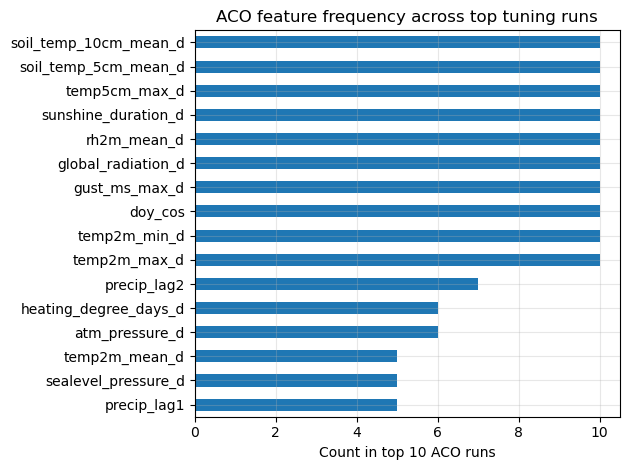

In [24]:
top_n = 10
top_aco = aco_tuning_df.head(top_n)

feature_counts = pd.Series(0, index=CANDIDATE_FEATURES, dtype=int)
for subset in top_aco["best_subset"]:
    for f in subset:
        feature_counts[f] += 1

feature_freq = (
    feature_counts.sort_values(ascending=False)
    .rename("count")
    .to_frame()
)
feature_freq["share"] = feature_freq["count"] / top_n

display(feature_freq.head(16))

plt.figure(figsize=(8, 6))
feature_freq.head(16).sort_values("count").plot(kind="barh", y="count", legend=False)
plt.xlabel(f"Count in top {top_n} ACO runs")
plt.title("ACO feature frequency across top tuning runs")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

gust_ms_max_d            2.815758
rh2m_mean_d              2.815066
doy_cos                  2.786994
global_radiation_d       2.431449
temp5cm_max_d            2.074354
temp2m_max_d             2.005722
heating_degree_days_d    1.946011
sunshine_duration_d      1.870269
soil_temp_5cm_mean_d     1.816380
temp2m_mean_d            1.799141
temp2m_min_d             1.627140
month                    1.516123
year                     1.400986
soil_temp_10cm_mean_d    1.393771
sealevel_pressure_d      1.208366
Name: pheromone, dtype: float64

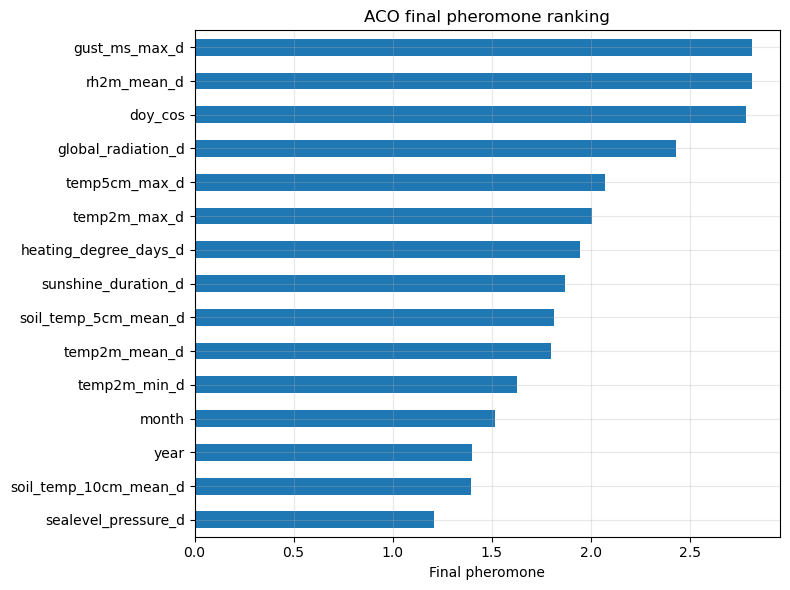

In [25]:
pheromone_series = pd.Series(
    aco_out["pheromone"],
    index=CANDIDATE_FEATURES,
    name="pheromone"
).sort_values(ascending=False)

display(pheromone_series.head(15))

plt.figure(figsize=(8, 6))
pheromone_series.head(15).sort_values().plot(kind="barh")
plt.xlabel("Final pheromone")
plt.title("ACO final pheromone ranking")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


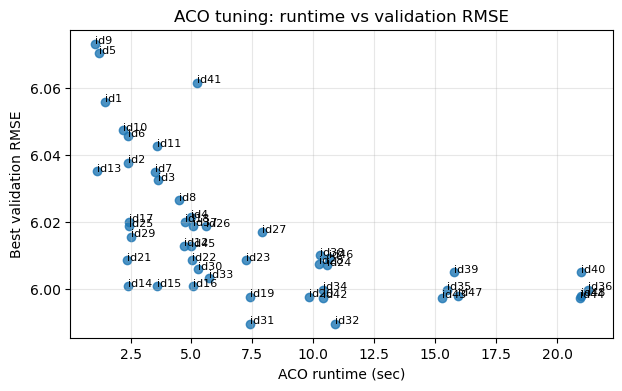

In [26]:
plt.figure(figsize=(7, 4))
plt.scatter(aco_tuning_df["runtime_sec"], aco_tuning_df["best_val_rmse"], alpha=0.8)

for _, row in aco_tuning_df.iterrows():
    plt.annotate(
        f"id{int(row['config_id'])}",
        (row["runtime_sec"], row["best_val_rmse"]),
        fontsize=8
    )

plt.xlabel("ACO runtime (sec)")
plt.ylabel("Best validation RMSE")
plt.title("ACO tuning: runtime vs validation RMSE")
plt.grid(alpha=0.3)
plt.show()

## Test Algorithms on Feature Subset

We define a grid for hyperparameter tuning of each algorithm. In order to keep all methods comparable we do not finetune the regularization term `l2`. 

In [27]:
# Compare GD vs SA vs GA vs Linear Regression (Baseline) on the FIXED best subset

Xtr_subset = X_train[:, best_idx]
Xva_subset = X_tune[:, best_idx]
Xte_subset = X_test[:, best_idx]

# Define grids for parameter tuning
gd_grid = [
    GDConfig(lr=0.001, steps=5000, l2=0.0, tol=1e-8),
    GDConfig(lr=0.01, steps=5000, l2=0.0, tol=1e-8),
    GDConfig(lr=0.1, steps=5000, l2=0.0, tol=1e-8),

    GDConfig(lr=0.001, steps=10000, l2=0.0, tol=1e-8),   
    GDConfig(lr=0.01, steps=10000, l2=0.0, tol=1e-8),
    GDConfig(lr=0.1, steps=10000, l2=0.0, tol=1e-8),

    GDConfig(lr=0.001, steps=20000, l2=0.0, tol=1e-8),   
    GDConfig(lr=0.01, steps=20000, l2=0.0, tol=1e-8),
    GDConfig(lr=0.1, steps=20000, l2=0.0, tol=1e-8),
]

sa_grid = [
    SAConfig(steps=5000, T0=0.5, alpha=0.995, step_sigma=0.01, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=5000, T0=0.5, alpha=0.997, step_sigma=0.05, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=5000, T0=0.5, alpha=0.999, step_sigma=0.1, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=5000, T0=0.5, alpha=0.995, step_sigma=0.01, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=5000, T0=0.5, alpha=0.997, step_sigma=0.05, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=5000, T0=0.5, alpha=0.999, step_sigma=0.1, l2=0.0, seed=RANDOM_SEED),

    SAConfig(steps=5000, T0=1.0, alpha=0.995, step_sigma=0.01, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=5000, T0=1.0, alpha=0.997, step_sigma=0.05, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=5000, T0=1.0, alpha=0.999, step_sigma=0.1, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=5000, T0=1.0, alpha=0.995, step_sigma=0.01, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=5000, T0=1.0, alpha=0.997, step_sigma=0.05, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=5000, T0=1.0, alpha=0.999, step_sigma=0.1, l2=0.0, seed=RANDOM_SEED),

    SAConfig(steps=5000, T0=2.0, alpha=0.995, step_sigma=0.01, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=5000, T0=2.0, alpha=0.997, step_sigma=0.05, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=5000, T0=2.0, alpha=0.999, step_sigma=0.1, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=5000, T0=2.0, alpha=0.995, step_sigma=0.01, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=5000, T0=2.0, alpha=0.997, step_sigma=0.05, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=5000, T0=2.0, alpha=0.999, step_sigma=0.1, l2=0.0, seed=RANDOM_SEED),

    SAConfig(steps=10000, T0=0.5, alpha=0.995, step_sigma=0.01, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=10000, T0=0.5, alpha=0.997, step_sigma=0.05, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=10000, T0=0.5, alpha=0.999, step_sigma=0.1, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=10000, T0=0.5, alpha=0.995, step_sigma=0.01, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=10000, T0=0.5, alpha=0.997, step_sigma=0.05, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=10000, T0=0.5, alpha=0.999, step_sigma=0.1, l2=0.0, seed=RANDOM_SEED),

    SAConfig(steps=10000, T0=1.0, alpha=0.995, step_sigma=0.01, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=10000, T0=1.0, alpha=0.997, step_sigma=0.05, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=10000, T0=1.0, alpha=0.999, step_sigma=0.1, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=10000, T0=1.0, alpha=0.995, step_sigma=0.01, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=10000, T0=1.0, alpha=0.997, step_sigma=0.05, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=10000, T0=1.0, alpha=0.999, step_sigma=0.1, l2=0.0, seed=RANDOM_SEED),

    SAConfig(steps=10000, T0=2.0, alpha=0.995, step_sigma=0.01, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=10000, T0=2.0, alpha=0.997, step_sigma=0.05, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=10000, T0=2.0, alpha=0.999, step_sigma=0.1, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=10000, T0=2.0, alpha=0.995, step_sigma=0.01, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=10000, T0=2.0, alpha=0.997, step_sigma=0.05, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=10000, T0=2.0, alpha=0.999, step_sigma=0.1, l2=0.0, seed=RANDOM_SEED),

    SAConfig(steps=20000, T0=0.5, alpha=0.995, step_sigma=0.01, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=20000, T0=0.5, alpha=0.997, step_sigma=0.05, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=20000, T0=0.5, alpha=0.999, step_sigma=0.1, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=20000, T0=0.5, alpha=0.995, step_sigma=0.01, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=20000, T0=0.5, alpha=0.997, step_sigma=0.05, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=20000, T0=0.5, alpha=0.999, step_sigma=0.1, l2=0.0, seed=RANDOM_SEED),

    SAConfig(steps=20000, T0=1.0, alpha=0.995, step_sigma=0.01, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=20000, T0=1.0, alpha=0.997, step_sigma=0.05, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=20000, T0=1.0, alpha=0.999, step_sigma=0.1, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=20000, T0=1.0, alpha=0.995, step_sigma=0.01, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=20000, T0=1.0, alpha=0.997, step_sigma=0.05, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=20000, T0=1.0, alpha=0.999, step_sigma=0.1, l2=0.0, seed=RANDOM_SEED),

    SAConfig(steps=20000, T0=2.0, alpha=0.995, step_sigma=0.01, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=20000, T0=2.0, alpha=0.997, step_sigma=0.05, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=20000, T0=2.0, alpha=0.999, step_sigma=0.1, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=20000, T0=2.0, alpha=0.995, step_sigma=0.01, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=20000, T0=2.0, alpha=0.997, step_sigma=0.05, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=20000, T0=2.0, alpha=0.999, step_sigma=0.1, l2=0.0, seed=RANDOM_SEED),
]

ga_grid = [
    GAConfig(pop_size=50,  generations=150, elite=4, mutation_rate=0.2, mutation_sigma=0.10, init_sigma=0.10, seed=RANDOM_SEED),
    GAConfig(pop_size=100, generations=250, elite=6, mutation_rate=0.3, mutation_sigma=0.10, init_sigma=0.10, seed=RANDOM_SEED),
    GAConfig(pop_size=150, generations=250, elite=6, mutation_rate=0.3, mutation_sigma=0.10, init_sigma=0.10, seed=RANDOM_SEED),
    GAConfig(pop_size=100, generations=400, elite=6, mutation_rate=0.3, mutation_sigma=0.10, init_sigma=0.10, seed=RANDOM_SEED), 
    GAConfig(pop_size=100, generations=250, elite=6, mutation_rate=0.5, mutation_sigma=0.15, init_sigma=0.10, seed=RANDOM_SEED),
]

tuning_rows = []

lr_res = evaluate_method_on_validation("LR", Xtr_subset, y_train_model, Xva_subset, y_tune, cfg=None)
tuning_rows.append({
    "method": "LR",
    "config_label": "default",
    "val_rmse": lr_res["val_rmse"],
    "runtime_sec": lr_res["runtime_sec"],
    "cfg_obj": None
})

for i, cfg in enumerate(gd_grid, start=1):
    res = evaluate_method_on_validation("GD", Xtr_subset, y_train_model, Xva_subset, y_tune, cfg=cfg)
    if np.isfinite(res["val_rmse"]):
        tuning_rows.append({
            "method": "GD",
            "config_label": f"gd_{i}",
            "val_rmse": res["val_rmse"],
            "runtime_sec": res["runtime_sec"],
            "cfg_obj": cfg
        })

for i, cfg in enumerate(sa_grid, start=1):
    res = evaluate_method_on_validation("SA", Xtr_subset, y_train_model, Xva_subset, y_tune, cfg=cfg)
    if np.isfinite(res["val_rmse"]):
        tuning_rows.append({
            "method": "SA",
            "config_label": f"sa_{i}",
            "val_rmse": res["val_rmse"],
            "runtime_sec": res["runtime_sec"],
            "cfg_obj": cfg
        })

for i, cfg in enumerate(ga_grid, start=1):
    res = evaluate_method_on_validation("GA", Xtr_subset, y_train_model, Xva_subset, y_tune, cfg=cfg)
    if np.isfinite(res["val_rmse"]):
        tuning_rows.append({
            "method": "GA",
            "config_label": f"ga_{i}",
            "val_rmse": res["val_rmse"],
            "runtime_sec": res["runtime_sec"],
            "cfg_obj": cfg
        })

tuning_df = pd.DataFrame(tuning_rows).sort_values(["method", "val_rmse"]).reset_index(drop=True)
tuning_df[["method", "config_label", "val_rmse", "runtime_sec"]]

best_cfg_by_method = {}

for method in ["GD", "SA", "GA"]:
    row = tuning_df[tuning_df["method"] == method].sort_values("val_rmse").iloc[0]
    best_cfg_by_method[method] = row["cfg_obj"]

print("Best GD config:", best_cfg_by_method["GD"])
print("Best SA config:", best_cfg_by_method["SA"])
print("Best GA config:", best_cfg_by_method["GA"])


Best GD config: GDConfig(lr=0.1, steps=20000, l2=0.0, tol=1e-08)
Best SA config: SAConfig(steps=5000, T0=0.5, alpha=0.999, step_sigma=0.1, l2=0.0, seed=42)
Best GA config: GAConfig(pop_size=150, generations=250, elite=6, tournament_k=3, crossover_rate=0.9, mutation_rate=0.3, mutation_sigma=0.1, init_sigma=0.1, l2=0.0, seed=42)


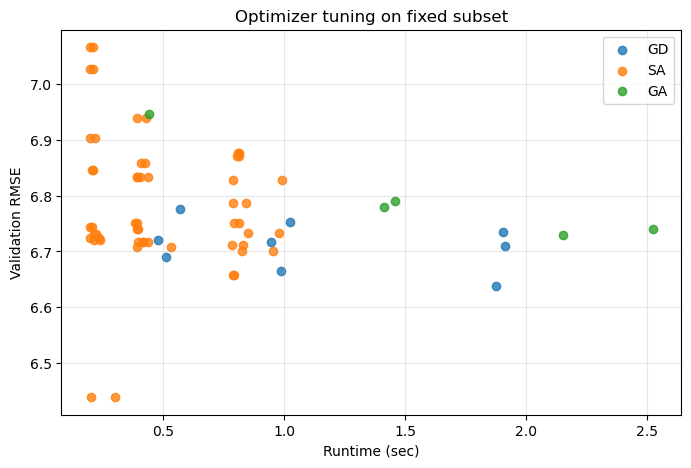

In [28]:
plt.figure(figsize=(8, 5))

for method in ["GD", "SA", "GA"]:
    sub = tuning_df[tuning_df["method"] == method]
    plt.scatter(sub["runtime_sec"], sub["val_rmse"], alpha=0.8, label=method)

plt.xlabel("Runtime (sec)")
plt.ylabel("Validation RMSE")
plt.title("Optimizer tuning on fixed subset")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Hyperparameter tuning showed that all algorithms benefit from longer optimization runs: GD and SA used 20'000 and 5'000 steps respectively, and the best GA run used 250 generations. 

In [29]:
# For refitting we use train + selection + tuning data (all data except test)
Xtr_refit = np.vstack([X_train, X_sel, X_tune])[:, best_idx]
y_tr_refit_model = np.hstack([y_train_model, y_sel_model, y_tune_model])
Xte_subset = X_test[:, best_idx]          

subset_eval = {
    "preds": {},
    "weights": {},
    "histories": {},
    "runtimes": {},
    "metrics": {}
}

# LR
start = time.time()
lr_subset = LinearRegression()
lr_subset.fit(Xtr_refit, y_tr_refit_model)
subset_eval["runtimes"]["LR"] = time.time() - start

subset_eval["preds"]["LR"] = prediction_to_original_scale(lr_subset.predict(Xte_subset))
subset_eval["weights"]["LR"] = lr_subset.coef_
subset_eval["histories"]["LR"] = None

# GD
start = time.time()
w_gd_subset, hist_gd_subset = fit_gd(Xtr_refit, y_tr_refit_model, best_cfg_by_method["GD"])
subset_eval["runtimes"]["GD"] = time.time() - start

subset_eval["preds"]["GD"] = prediction_to_original_scale(add_bias(Xte_subset) @ w_gd_subset)
subset_eval["weights"]["GD"] = w_gd_subset
subset_eval["histories"]["GD"] = hist_gd_subset

# SA
start = time.time()
w_sa_subset, hist_sa_subset = fit_sa(Xtr_refit, y_tr_refit_model, best_cfg_by_method["SA"])
subset_eval["runtimes"]["SA"] = time.time() - start

subset_eval["preds"]["SA"] = prediction_to_original_scale(add_bias(Xte_subset) @ w_sa_subset)
subset_eval["weights"]["SA"] = w_sa_subset
subset_eval["histories"]["SA"] = hist_sa_subset

# GA
start = time.time()
w_ga_subset, hist_ga_subset = fit_ga(Xtr_refit, y_tr_refit_model, best_cfg_by_method["GA"])
subset_eval["runtimes"]["GA"] = time.time() - start

subset_eval["preds"]["GA"] = prediction_to_original_scale(add_bias(Xte_subset) @ w_ga_subset)
subset_eval["weights"]["GA"] = w_ga_subset
subset_eval["histories"]["GA"] = hist_ga_subset

# Metrics
for method, pred in subset_eval["preds"].items():
    subset_eval["metrics"][method] = {
        "test_rmse": float(np.sqrt(mean_squared_error(y_test, pred))),
        "test_mae": float(mean_absolute_error(y_test, pred)),
        "test_r2": float(r2_score(y_test, pred)),
        "runtime_sec": float(subset_eval["runtimes"][method]),
        "subset_size": int(len(best_subset)),
    }

subset_rows = []
for method in subset_eval["preds"].keys():
    row = {"method": method}
    row.update(subset_eval["metrics"][method])
    subset_rows.append(row)

subset_results = pd.DataFrame(subset_rows).sort_values("test_rmse").reset_index(drop=True)

subset_eval["results_df"] = subset_results
subset_results


,method,test_rmse,test_mae,test_r2,runtime_sec,subset_size
0,LR,6.601380,3.193100,0.301998,0.004000,16
1,GD,6.626370,3.197220,0.296703,2.349448,16
2,GA,6.743004,3.261168,0.271727,2.507552,16
3,SA,6.790616,3.411704,0.261406,0.222066,16


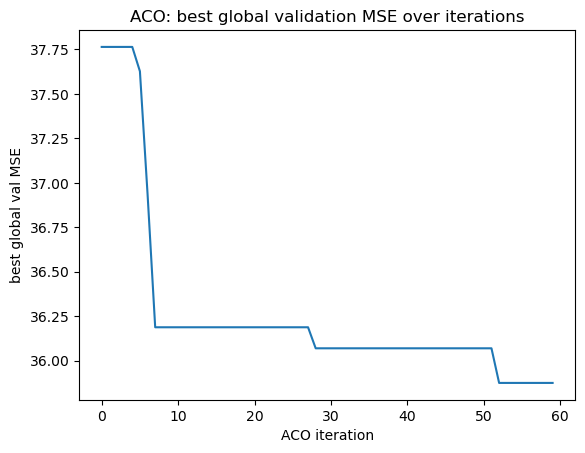

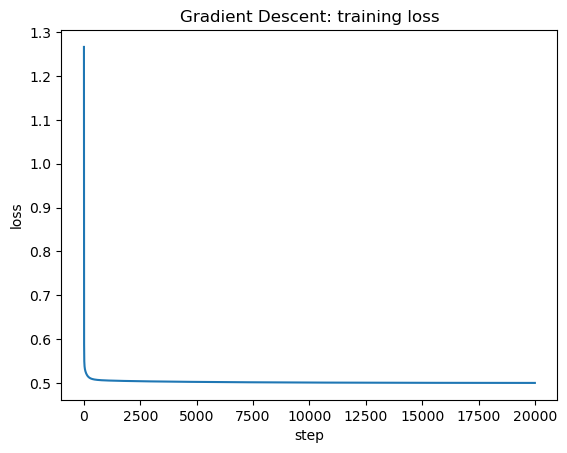

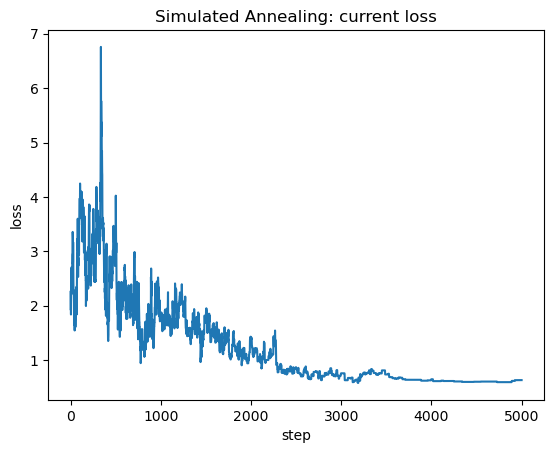

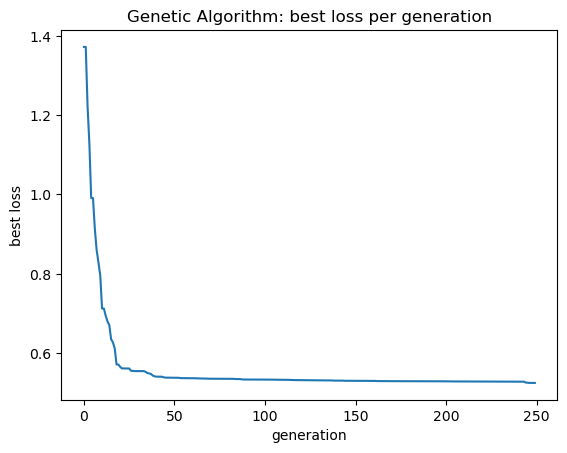

In [30]:
plt.figure()
plt.plot(aco_out["trace"]["best_global_mse"].to_numpy())
plt.title("ACO: best global validation MSE over iterations")
plt.xlabel("ACO iteration")
plt.ylabel("best global val MSE")
plt.show()

plt.figure()
plt.plot(subset_eval["histories"]["GD"])
plt.title("Gradient Descent: training loss")
plt.xlabel("step")
plt.ylabel("loss")
plt.show()

plt.figure()
plt.plot(subset_eval["histories"]["SA"])
plt.title("Simulated Annealing: current loss")
plt.xlabel("step")
plt.ylabel("loss")
plt.show()

plt.figure()
plt.plot(subset_eval["histories"]["GA"])
plt.title("Genetic Algorithm: best loss per generation")
plt.xlabel("generation")
plt.ylabel("best loss")
plt.show()

In [31]:
def plot_prediction_diagnostics(y_true, y_pred, model_name, bins=40):
    resid = y_true - y_pred

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # 1) Predicted vs actual
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())

    axes[0].scatter(y_true, y_pred, alpha=0.4)
    axes[0].plot([lo, hi], [lo, hi], linestyle="--")
    axes[0].set_xlabel("Actual precipitation")
    axes[0].set_ylabel("Predicted precipitation")
    axes[0].set_title(f"{model_name}: predicted vs actual")
    axes[0].grid(alpha=0.3)

    # 2) Residual histogram
    axes[1].hist(resid, bins=bins)
    axes[1].set_xlabel("Residual (actual - predicted)")
    axes[1].set_ylabel("Count")
    axes[1].set_title(f"{model_name}: residual distribution")
    axes[1].grid(alpha=0.3)

    # 3) Residuals vs fitted
    axes[2].scatter(y_pred, resid, alpha=0.4)
    axes[2].axhline(0, linestyle="--")
    axes[2].set_xlabel("Predicted precipitation")
    axes[2].set_ylabel("Residual")
    axes[2].set_title(f"{model_name}: residuals vs fitted")
    axes[2].grid(alpha=0.3)

    fig.suptitle(f"Prediction diagnostics — {model_name}", y=1.05)
    plt.tight_layout()
    plt.show()


def plot_diagnostics_grid(eval_dict, y_true, methods=None, bins=40, title_prefix=""):
    if methods is None:
        methods = list(eval_dict["preds"].keys())

    fig, axes = plt.subplots(len(methods), 3, figsize=(16, 4 * len(methods)))
    if len(methods) == 1:
        axes = np.array([axes])

    for row, method in enumerate(methods):
        y_pred = eval_dict["preds"][method]
        resid = y_true - y_pred

        lo = min(y_true.min(), y_pred.min())
        hi = max(y_true.max(), y_pred.max())

        axes[row, 0].scatter(y_true, y_pred, alpha=0.4)
        axes[row, 0].plot([lo, hi], [lo, hi], linestyle="--")
        axes[row, 0].set_xlabel("Actual precipitation")
        axes[row, 0].set_ylabel("Predicted precipitation")
        axes[row, 0].set_title(f"{method}: predicted vs actual")
        axes[row, 0].grid(alpha=0.3)

        axes[row, 1].hist(resid, bins=bins)
        axes[row, 1].set_xlabel("Residual (actual - predicted)")
        axes[row, 1].set_ylabel("Count")
        axes[row, 1].set_title(f"{method}: residual distribution")
        axes[row, 1].grid(alpha=0.3)

        axes[row, 2].scatter(y_pred, resid, alpha=0.4)
        axes[row, 2].axhline(0, linestyle="--")
        axes[row, 2].set_xlabel("Predicted precipitation")
        axes[row, 2].set_ylabel("Residual")
        axes[row, 2].set_title(f"{method}: residuals vs fitted")
        axes[row, 2].grid(alpha=0.3)

    fig.suptitle(f"{title_prefix} prediction diagnostics", y=1.01, fontsize=14)
    plt.tight_layout()
    plt.show()


def get_used_split_frame(df, feature_cols, target_col, station_col, date_col):
    used_cols = feature_cols + [target_col, station_col, date_col]
    d = df.copy()
    d = d.dropna(subset=[c for c in used_cols if c is not None]).reset_index(drop=True)
    d[date_col] = pd.to_datetime(d[date_col])
    d = d.sort_values([station_col, date_col]).reset_index(drop=True)
    return d


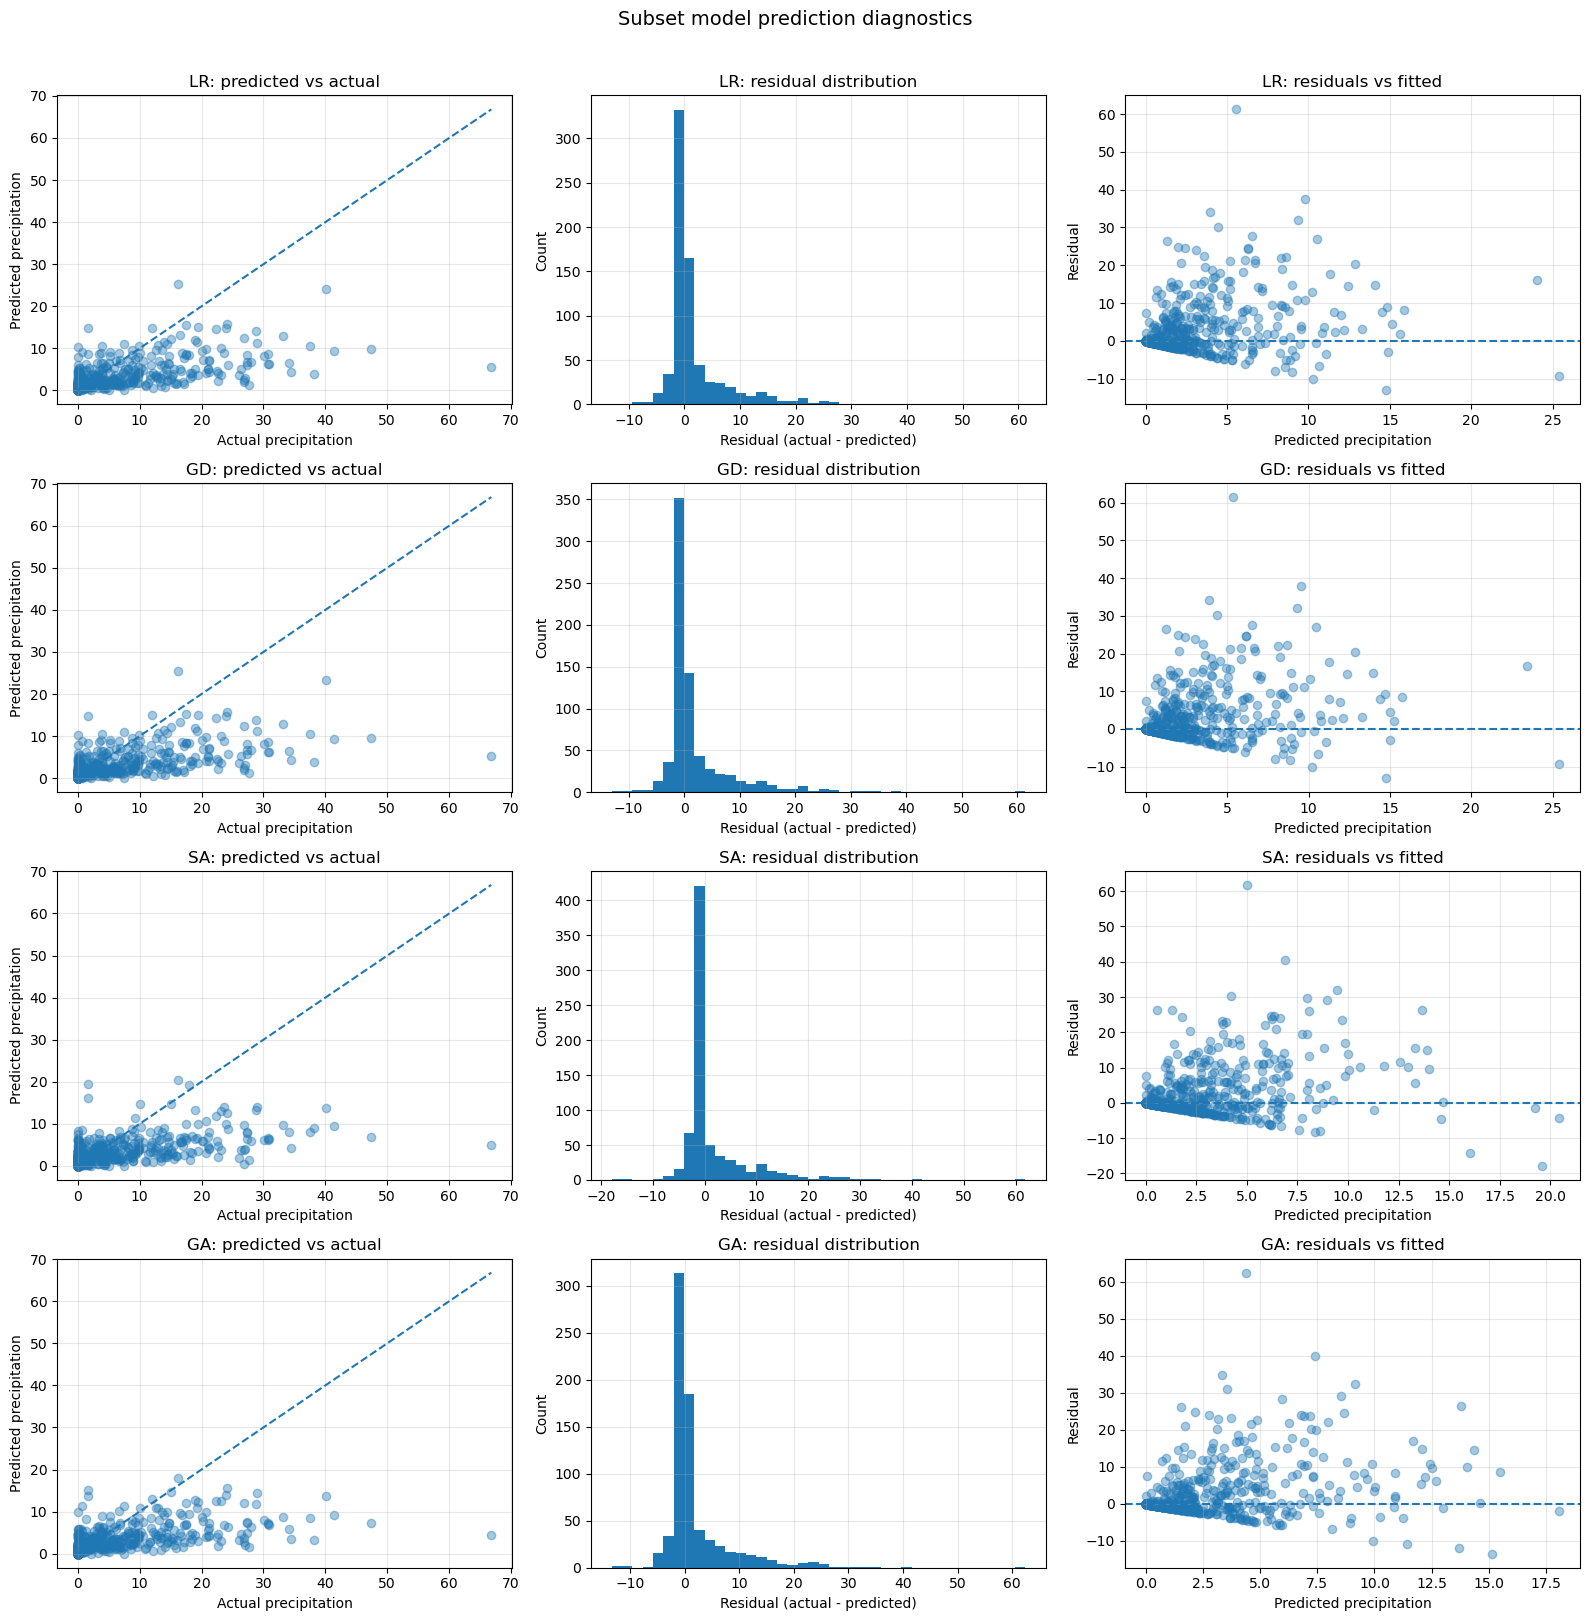

In [32]:
plot_diagnostics_grid(
    eval_dict=subset_eval,
    y_true=y_test,
    methods=["LR", "GD", "SA", "GA"],
    title_prefix="Subset model"
)


In [33]:
# Robustness Check: repeat the final optimizers on the fixed best subset, refit on all non-test data 

def run_optimizers_on_subset(seed: int) -> Dict:
    Xref = np.vstack([X_train, X_sel, X_tune])[:, best_idx]
    yref_model = np.hstack([y_train_model, y_sel_model, y_tune_model])
    Xte = X_test[:, best_idx]

    start = time.time()
    lr = LinearRegression()
    lr.fit(Xref, yref_model)
    runtime_lr = time.time() - start
    pred_lr = prediction_to_original_scale(lr.predict(Xte))

    gd_cfg = best_cfg_by_method["GD"]
    start = time.time()
    w_gd, _ = fit_gd(Xref, yref_model, gd_cfg)
    runtime_gd = time.time() - start
    pred_gd = prediction_to_original_scale(add_bias(Xte) @ w_gd)

    sa_cfg_base = best_cfg_by_method["SA"]
    sa_cfg = SAConfig(
        steps=sa_cfg_base.steps,
        T0=sa_cfg_base.T0,
        alpha=sa_cfg_base.alpha,
        step_sigma=sa_cfg_base.step_sigma,
        l2=sa_cfg_base.l2,
        seed=seed,
    )
    start = time.time()
    w_sa, _ = fit_sa(Xref, yref_model, sa_cfg)
    runtime_sa = time.time() - start
    pred_sa = prediction_to_original_scale(add_bias(Xte) @ w_sa)

    ga_cfg_base = best_cfg_by_method["GA"]
    ga_cfg = GAConfig(
        pop_size=ga_cfg_base.pop_size,
        generations=ga_cfg_base.generations,
        elite=ga_cfg_base.elite,
        mutation_rate=ga_cfg_base.mutation_rate,
        mutation_sigma=ga_cfg_base.mutation_sigma,
        init_sigma=ga_cfg_base.init_sigma,
        seed=seed,
    )
    start = time.time()
    w_ga, _ = fit_ga(Xref, yref_model, ga_cfg)
    runtime_ga = time.time() - start
    pred_ga = prediction_to_original_scale(add_bias(Xte) @ w_ga)

    return {
        "seed": seed,
        "rmse_lr": float(np.sqrt(mean_squared_error(y_test, pred_lr))),
        "rmse_gd": float(np.sqrt(mean_squared_error(y_test, pred_gd))),
        "rmse_sa": float(np.sqrt(mean_squared_error(y_test, pred_sa))),
        "rmse_ga": float(np.sqrt(mean_squared_error(y_test, pred_ga))),
        "mae_lr": float(mean_absolute_error(y_test, pred_lr)),
        "mae_gd": float(mean_absolute_error(y_test, pred_gd)),
        "mae_sa": float(mean_absolute_error(y_test, pred_sa)),
        "mae_ga": float(mean_absolute_error(y_test, pred_ga)),
        "r2_lr": float(r2_score(y_test, pred_lr)),
        "r2_gd": float(r2_score(y_test, pred_gd)),
        "r2_sa": float(r2_score(y_test, pred_sa)),
        "r2_ga": float(r2_score(y_test, pred_ga)),
        "runtime_lr": float(runtime_lr),
        "runtime_gd": float(runtime_gd),
        "runtime_sa": float(runtime_sa),
        "runtime_ga": float(runtime_ga),
    }

seeds = [1, 2, 3, 4, 5]
rob = pd.DataFrame([run_optimizers_on_subset(s) for s in seeds])
rob


,seed,rmse_lr,rmse_gd,rmse_sa,rmse_ga,mae_lr,mae_gd,mae_sa,mae_ga,r2_lr,r2_gd,r2_sa,r2_ga,runtime_lr,runtime_gd,runtime_sa,runtime_ga
0,1,6.60138,6.62637,7.459133,6.816904,3.1931,3.19722,3.498726,3.290526,0.301998,0.296703,0.108822,0.255676,0.002002,2.379545,0.239053,2.509564
1,2,6.60138,6.62637,6.685214,6.823725,3.1931,3.19722,3.324903,3.299069,0.301998,0.296703,0.284156,0.254186,0.001000,2.340527,0.254057,2.402568
2,3,6.60138,6.62637,6.795761,6.844494,3.1931,3.19722,3.291455,3.302225,0.301998,0.296703,0.260286,0.249639,0.001000,2.301917,0.256059,2.518116
3,4,6.60138,6.62637,6.845635,6.819710,3.1931,3.19722,3.411961,3.297162,0.301998,0.296703,0.249389,0.255063,0.001001,2.326827,0.308070,2.535090
4,5,6.60138,6.62637,6.908084,6.735917,3.1931,3.19722,3.269731,3.268344,0.301998,0.296703,0.235631,0.273257,0.001000,2.332542,0.223934,2.536314


In [34]:
# Robustness Check 2: repeat the FULL ACO + optimizers pipeline with different seeds

def run_full_pipeline(seed: int) -> Dict:
    aco_cfg = ACOConfig(
        n_ants=30,
        n_iters=15,
        evaporation=0.2,
        q=1.0,
        top_k=8,
        subset_min=2,
        subset_max=min(12, len(CANDIDATE_FEATURES)),
        seed=seed
    )

    start = time.time()
    out = aco_feature_selection(
        X_train, y_train_model, X_sel, y_sel,
        CANDIDATE_FEATURES, aco_cfg
    )
    runtime_aco = time.time() - start

    subset = out["best"]["features"]
    idx = np.array([CANDIDATE_FEATURES.index(f) for f in subset], dtype=int)

    Xtr = X_train[:, idx]
    Xte = X_test[:, idx]

    start = time.time()
    lr = LinearRegression()
    lr.fit(Xtr, y_train_model)
    runtime_lr = time.time() - start
    pred_lr = prediction_to_original_scale(lr.predict(Xte))

    rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
    mae_lr = mean_absolute_error(y_test, pred_lr)
    r2_lr = r2_score(y_test, pred_lr)

    start = time.time()
    w_gd, _ = fit_gd(Xtr, y_train_model, GDConfig(lr=0.05, steps=2500, l2=0.0))
    runtime_gd = time.time() - start
    pred_gd = prediction_to_original_scale(add_bias(Xte) @ w_gd)

    rmse_gd = np.sqrt(mean_squared_error(y_test, pred_gd))
    mae_gd = mean_absolute_error(y_test, pred_gd)
    r2_gd = r2_score(y_test, pred_gd)

    start = time.time()
    w_sa, _ = fit_sa(
        Xtr, y_train_model,
        SAConfig(
            steps=4000,
            T0=1.0,
            alpha=0.997,
            step_sigma=0.05,
            seed=seed
        )
    )
    runtime_sa = time.time() - start
    pred_sa = prediction_to_original_scale(add_bias(Xte) @ w_sa)

    rmse_sa = np.sqrt(mean_squared_error(y_test, pred_sa))
    mae_sa = mean_absolute_error(y_test, pred_sa)
    r2_sa = r2_score(y_test, pred_sa)

    start = time.time()
    w_ga, _ = fit_ga(
        Xtr, y_train_model,
        GAConfig(
            pop_size=100,
            generations=250,
            elite=6,
            mutation_rate=0.3,
            mutation_sigma=0.1,
            init_sigma=0.1,
            seed=seed
        )
    )
    runtime_ga = time.time() - start
    pred_ga = prediction_to_original_scale(add_bias(Xte) @ w_ga)

    rmse_ga = np.sqrt(mean_squared_error(y_test, pred_ga))
    mae_ga = mean_absolute_error(y_test, pred_ga)
    r2_ga = r2_score(y_test, pred_ga)

    return {
        "seed": seed,
        "subset_size": len(subset),
        "subset": ",".join(subset),
        "aco_val_mse": out["best"]["mse"],
        "runtime_aco": runtime_aco,
        "rmse_lr": rmse_lr,
        "mae_lr": mae_lr,
        "r2_lr": r2_lr,
        "runtime_lr": runtime_lr,
        "rmse_gd": rmse_gd,
        "mae_gd": mae_gd,
        "r2_gd": r2_gd,
        "runtime_gd": runtime_gd,
        "rmse_sa": rmse_sa,
        "mae_sa": mae_sa,
        "r2_sa": r2_sa,
        "runtime_sa": runtime_sa,
        "rmse_ga": rmse_ga,
        "mae_ga": mae_ga,
        "r2_ga": r2_ga,
        "runtime_ga": runtime_ga,
    }

seeds = [1, 2, 3]
full_rob = pd.DataFrame([run_full_pipeline(s) for s in seeds])
full_rob


,seed,subset_size,subset,aco_val_mse,runtime_aco,rmse_lr,mae_lr,r2_lr,runtime_lr,rmse_gd,...,r2_gd,runtime_gd,rmse_sa,mae_sa,r2_sa,runtime_sa,rmse_ga,mae_ga,r2_ga,runtime_ga
0,1,12,"doy_cos,wind_ms_mean_d,soil_temp_20cm_mean_d,s...",38.788354,0.848190,6.767710,3.243806,0.266380,0.002001,6.770012,...,0.265881,0.287065,6.801912,3.247998,0.258947,0.166037,6.852196,3.288013,0.247949,1.357504
1,2,12,"wind_ms_mean_d,temp2m_max_d,precip_lag1,vapor_...",37.510335,0.817797,6.811963,3.250825,0.256755,0.001999,6.849633,...,0.248512,0.278062,6.780342,3.262730,0.263639,0.144033,6.849158,3.292533,0.248616,1.375307
2,3,12,"temp5cm_max_d,gust_ms_max_d,wind_dir_mean_d,su...",37.479485,0.815183,6.882958,3.277799,0.241182,0.001001,6.821582,...,0.254654,0.280063,6.574798,3.270575,0.307607,0.155035,6.690956,3.345425,0.282926,1.426328


## Comparison of ACO subset Model vs Full Model

In order to consistently compare the full model to the subset model, the full model has to be tuned separately. Hence, we tune each algorithm on the same grid as the subset model and compare the results.

In [35]:
# Tune optimizers separately for the FULL feature model

Xtr_full_tune = X_train
Xva_full_tune = X_tune

full_tuning_rows = []

lr_full_tune = evaluate_method_on_validation("LR", Xtr_full_tune, y_train_model, Xva_full_tune, y_tune, cfg=None)
full_tuning_rows.append({
    "method": "LR",
    "config_label": "default",
    "val_rmse": lr_full_tune["val_rmse"],
    "runtime_sec": lr_full_tune["runtime_sec"],
    "cfg_obj": None,
})

for i, cfg in enumerate(gd_grid, start=1):
    res = evaluate_method_on_validation("GD", Xtr_full_tune, y_train_model, Xva_full_tune, y_tune, cfg=cfg)
    if np.isfinite(res["val_rmse"]):
        full_tuning_rows.append({
            "method": "GD",
            "config_label": f"gd_full_{i}",
            "val_rmse": res["val_rmse"],
            "runtime_sec": res["runtime_sec"],
            "cfg_obj": cfg,
        })

for i, cfg in enumerate(sa_grid, start=1):
    res = evaluate_method_on_validation("SA", Xtr_full_tune, y_train_model, Xva_full_tune, y_tune, cfg=cfg)
    if np.isfinite(res["val_rmse"]):
        full_tuning_rows.append({
            "method": "SA",
            "config_label": f"sa_full_{i}",
            "val_rmse": res["val_rmse"],
            "runtime_sec": res["runtime_sec"],
            "cfg_obj": cfg,
        })

for i, cfg in enumerate(ga_grid, start=1):
    res = evaluate_method_on_validation("GA", Xtr_full_tune, y_train_model, Xva_full_tune, y_tune, cfg=cfg)
    if np.isfinite(res["val_rmse"]):
        full_tuning_rows.append({
            "method": "GA",
            "config_label": f"ga_full_{i}",
            "val_rmse": res["val_rmse"],
            "runtime_sec": res["runtime_sec"],
            "cfg_obj": cfg,
        })

full_tuning_df = pd.DataFrame(full_tuning_rows).sort_values(["method", "val_rmse"]).reset_index(drop=True)
full_tuning_df[["method", "config_label", "val_rmse", "runtime_sec"]]

best_cfg_by_method_full = {}
for method in ["GD", "SA", "GA"]:
    row = full_tuning_df[full_tuning_df["method"] == method].sort_values("val_rmse").iloc[0]
    best_cfg_by_method_full[method] = row["cfg_obj"]

print("Best full GD config:", best_cfg_by_method_full["GD"])
print("Best full SA config:", best_cfg_by_method_full["SA"])
print("Best full GA config:", best_cfg_by_method_full["GA"])


Xtr_full = np.vstack([X_train, X_sel, X_tune])
ytr_full_model = np.hstack([y_train_model, y_sel_model, y_tune_model])
Xte_full = X_test

full_eval = {
    "preds": {},
    "weights": {},
    "histories": {},
    "runtimes": {},
    "metrics": {}
}

# LR FULL
start = time.time()
lr_full = LinearRegression()
lr_full.fit(Xtr_full, ytr_full_model)
full_eval["runtimes"]["LR"] = time.time() - start

full_eval["preds"]["LR"] = prediction_to_original_scale(lr_full.predict(Xte_full))
full_eval["weights"]["LR"] = lr_full.coef_
full_eval["histories"]["LR"] = None

# GD FULL
start = time.time()
w_gd_full, hist_gd_full = fit_gd(Xtr_full, ytr_full_model, best_cfg_by_method_full["GD"])
full_eval["runtimes"]["GD"] = time.time() - start

full_eval["preds"]["GD"] = prediction_to_original_scale(add_bias(Xte_full) @ w_gd_full)
full_eval["weights"]["GD"] = w_gd_full
full_eval["histories"]["GD"] = hist_gd_full

# SA FULL
sa_cfg_full_base = best_cfg_by_method_full["SA"]
sa_cfg_full = SAConfig(
    steps=sa_cfg_full_base.steps,
    T0=sa_cfg_full_base.T0,
    alpha=sa_cfg_full_base.alpha,
    step_sigma=sa_cfg_full_base.step_sigma,
    l2=sa_cfg_full_base.l2,
    seed=RANDOM_SEED,
)
start = time.time()
w_sa_full, hist_sa_full = fit_sa(Xtr_full, ytr_full_model, sa_cfg_full)
full_eval["runtimes"]["SA"] = time.time() - start

full_eval["preds"]["SA"] = prediction_to_original_scale(add_bias(Xte_full) @ w_sa_full)
full_eval["weights"]["SA"] = w_sa_full
full_eval["histories"]["SA"] = hist_sa_full

# GA FULL
ga_cfg_full_base = best_cfg_by_method_full["GA"]
ga_cfg_full = GAConfig(
    pop_size=ga_cfg_full_base.pop_size,
    generations=ga_cfg_full_base.generations,
    elite=ga_cfg_full_base.elite,
    tournament_k=ga_cfg_full_base.tournament_k,
    crossover_rate=ga_cfg_full_base.crossover_rate,
    mutation_rate=ga_cfg_full_base.mutation_rate,
    mutation_sigma=ga_cfg_full_base.mutation_sigma,
    init_sigma=ga_cfg_full_base.init_sigma,
    l2=ga_cfg_full_base.l2,
    seed=RANDOM_SEED,
)
start = time.time()
w_ga_full, hist_ga_full = fit_ga(Xtr_full, ytr_full_model, ga_cfg_full)
full_eval["runtimes"]["GA"] = time.time() - start

full_eval["preds"]["GA"] = prediction_to_original_scale(add_bias(Xte_full) @ w_ga_full)
full_eval["weights"]["GA"] = w_ga_full
full_eval["histories"]["GA"] = hist_ga_full

# Metrics
for method, pred in full_eval["preds"].items():
    full_eval["metrics"][method] = {
        "rmse_full": float(np.sqrt(mean_squared_error(y_test, pred))),
        "mae_full": float(mean_absolute_error(y_test, pred)),
        "r2_full": float(r2_score(y_test, pred)),
        "runtime_full": float(full_eval["runtimes"][method]),
    }

full_results = (
    pd.DataFrame(full_eval["metrics"])
    .T
    .reset_index()
    .rename(columns={"index": "method"})
    .sort_values("rmse_full")
    .reset_index(drop=True)
)

full_eval["results_df"] = full_results
full_results


c:\Users\Kai\anaconda3\envs\BioInspAlg\Lib\site-packages\numpy\_core\_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\Kai\AppData\Local\Temp\ipykernel_34780\902401239.py:72: RuntimeWarning: overflow encountered in expm1
  return np.expm1(y)


Best full GD config: GDConfig(lr=0.001, steps=20000, l2=0.0, tol=1e-08)
Best full SA config: SAConfig(steps=20000, T0=1.0, alpha=0.999, step_sigma=0.1, l2=0.0, seed=42)
Best full GA config: GAConfig(pop_size=150, generations=250, elite=6, tournament_k=3, crossover_rate=0.9, mutation_rate=0.3, mutation_sigma=0.1, init_sigma=0.1, l2=0.0, seed=42)


,method,rmse_full,mae_full,r2_full,runtime_full
0,GD,6.508992,3.176727,0.321398,2.749340
1,LR,6.534273,3.143766,0.316117,0.002001
2,GA,6.697796,3.264494,0.281459,2.792615
3,SA,7.139079,3.733261,0.183658,1.069259


In [36]:
comparison = subset_eval["results_df"].merge(full_eval["results_df"], on="method")
comparison

,method,test_rmse,test_mae,test_r2,runtime_sec,subset_size,rmse_full,mae_full,r2_full,runtime_full
0,LR,6.601380,3.193100,0.301998,0.004000,16,6.534273,3.143766,0.316117,0.002001
1,GD,6.626370,3.197220,0.296703,2.349448,16,6.508992,3.176727,0.321398,2.749340
2,GA,6.743004,3.261168,0.271727,2.507552,16,6.697796,3.264494,0.281459,2.792615
3,SA,6.790616,3.411704,0.261406,0.222066,16,7.139079,3.733261,0.183658,1.069259


In [37]:
print("Best subset model:", subset_eval["results_df"].iloc[0]["method"])
print("Best full model:", full_eval["results_df"].iloc[0]["method"])


Best subset model: LR
Best full model: GD


## Result Diagnostics

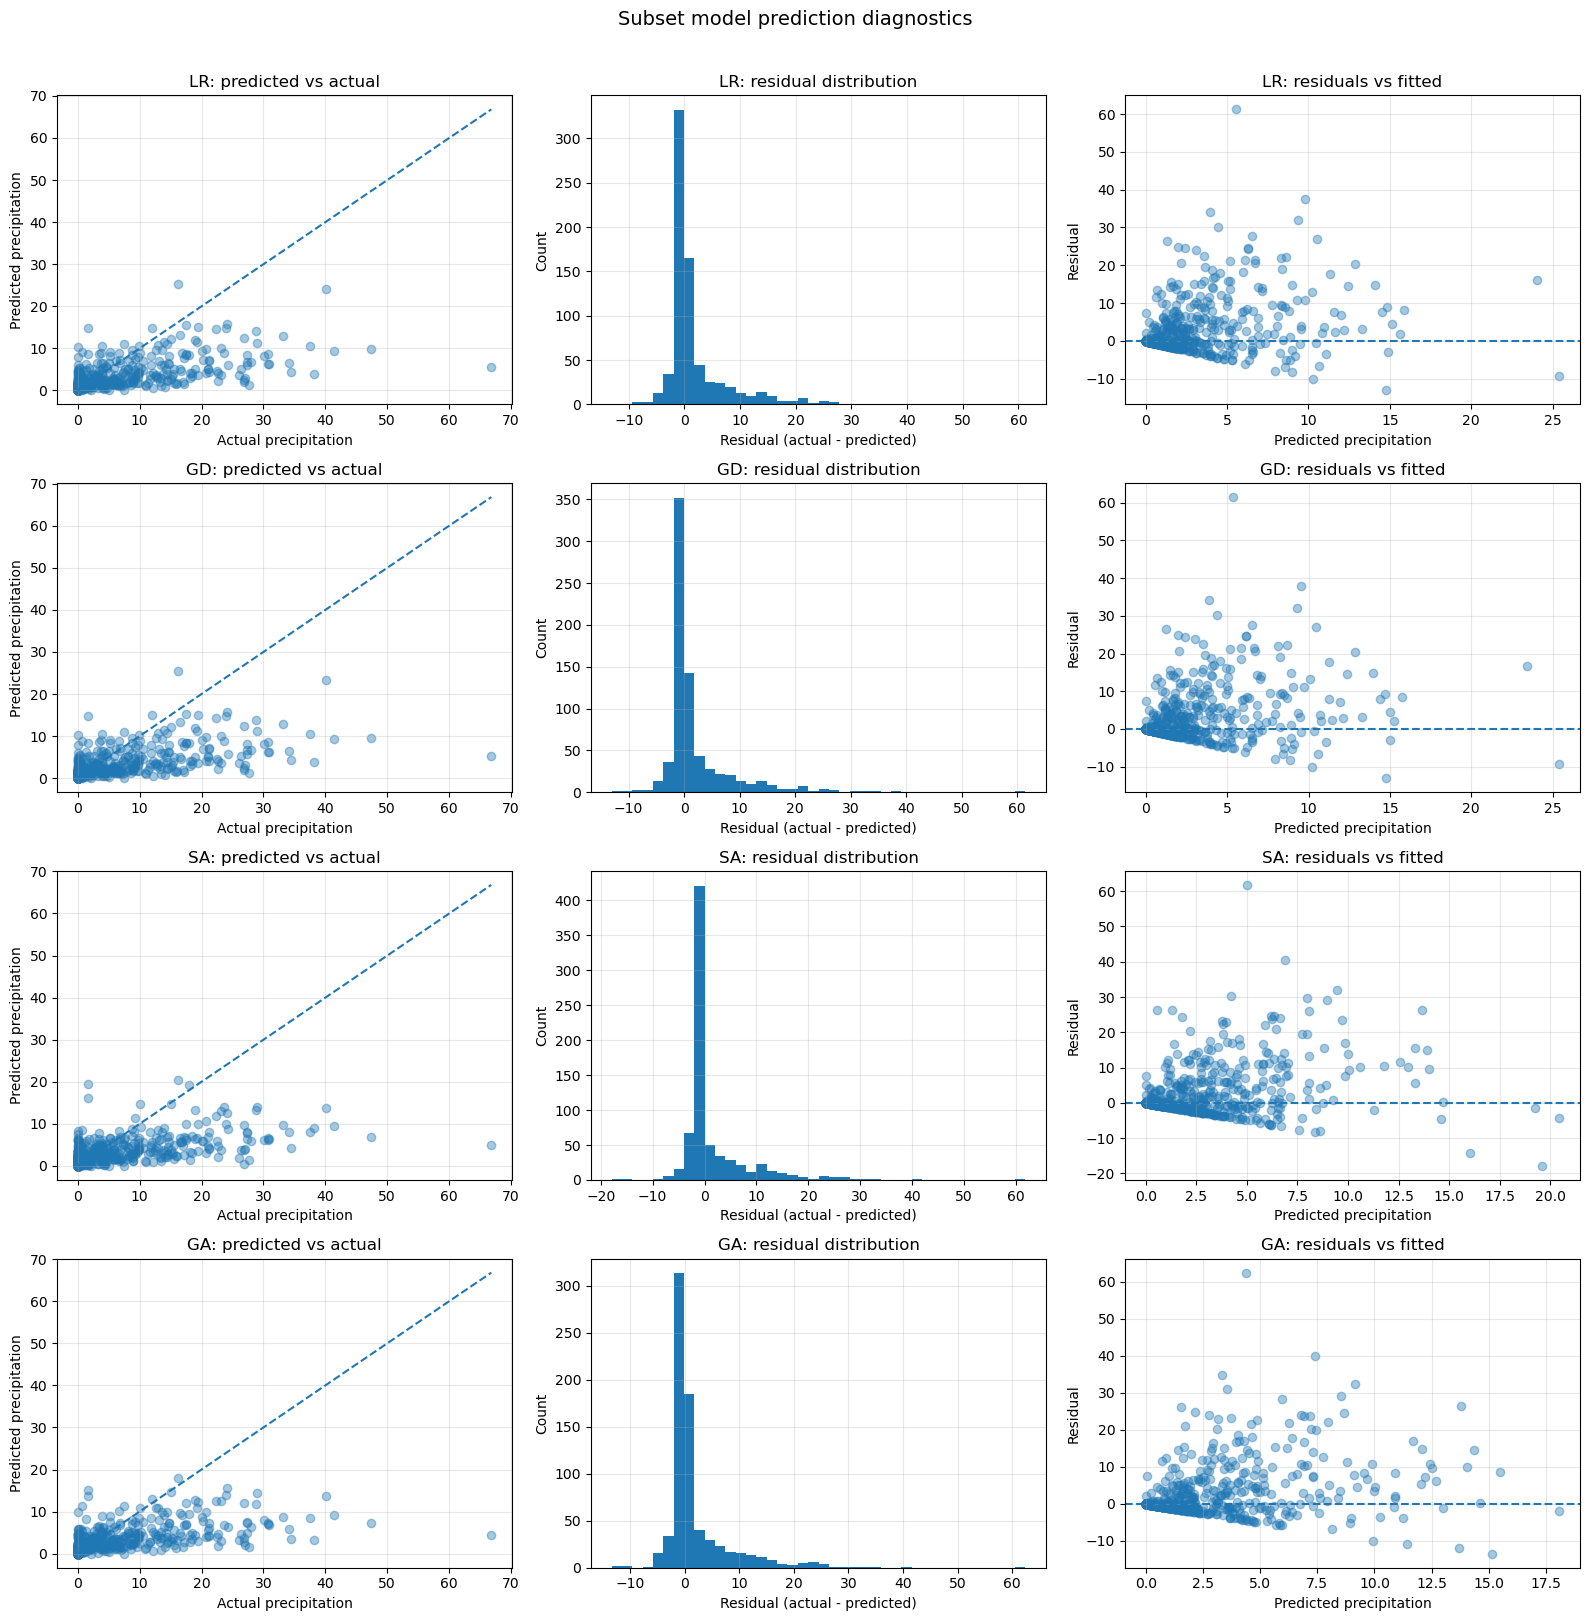

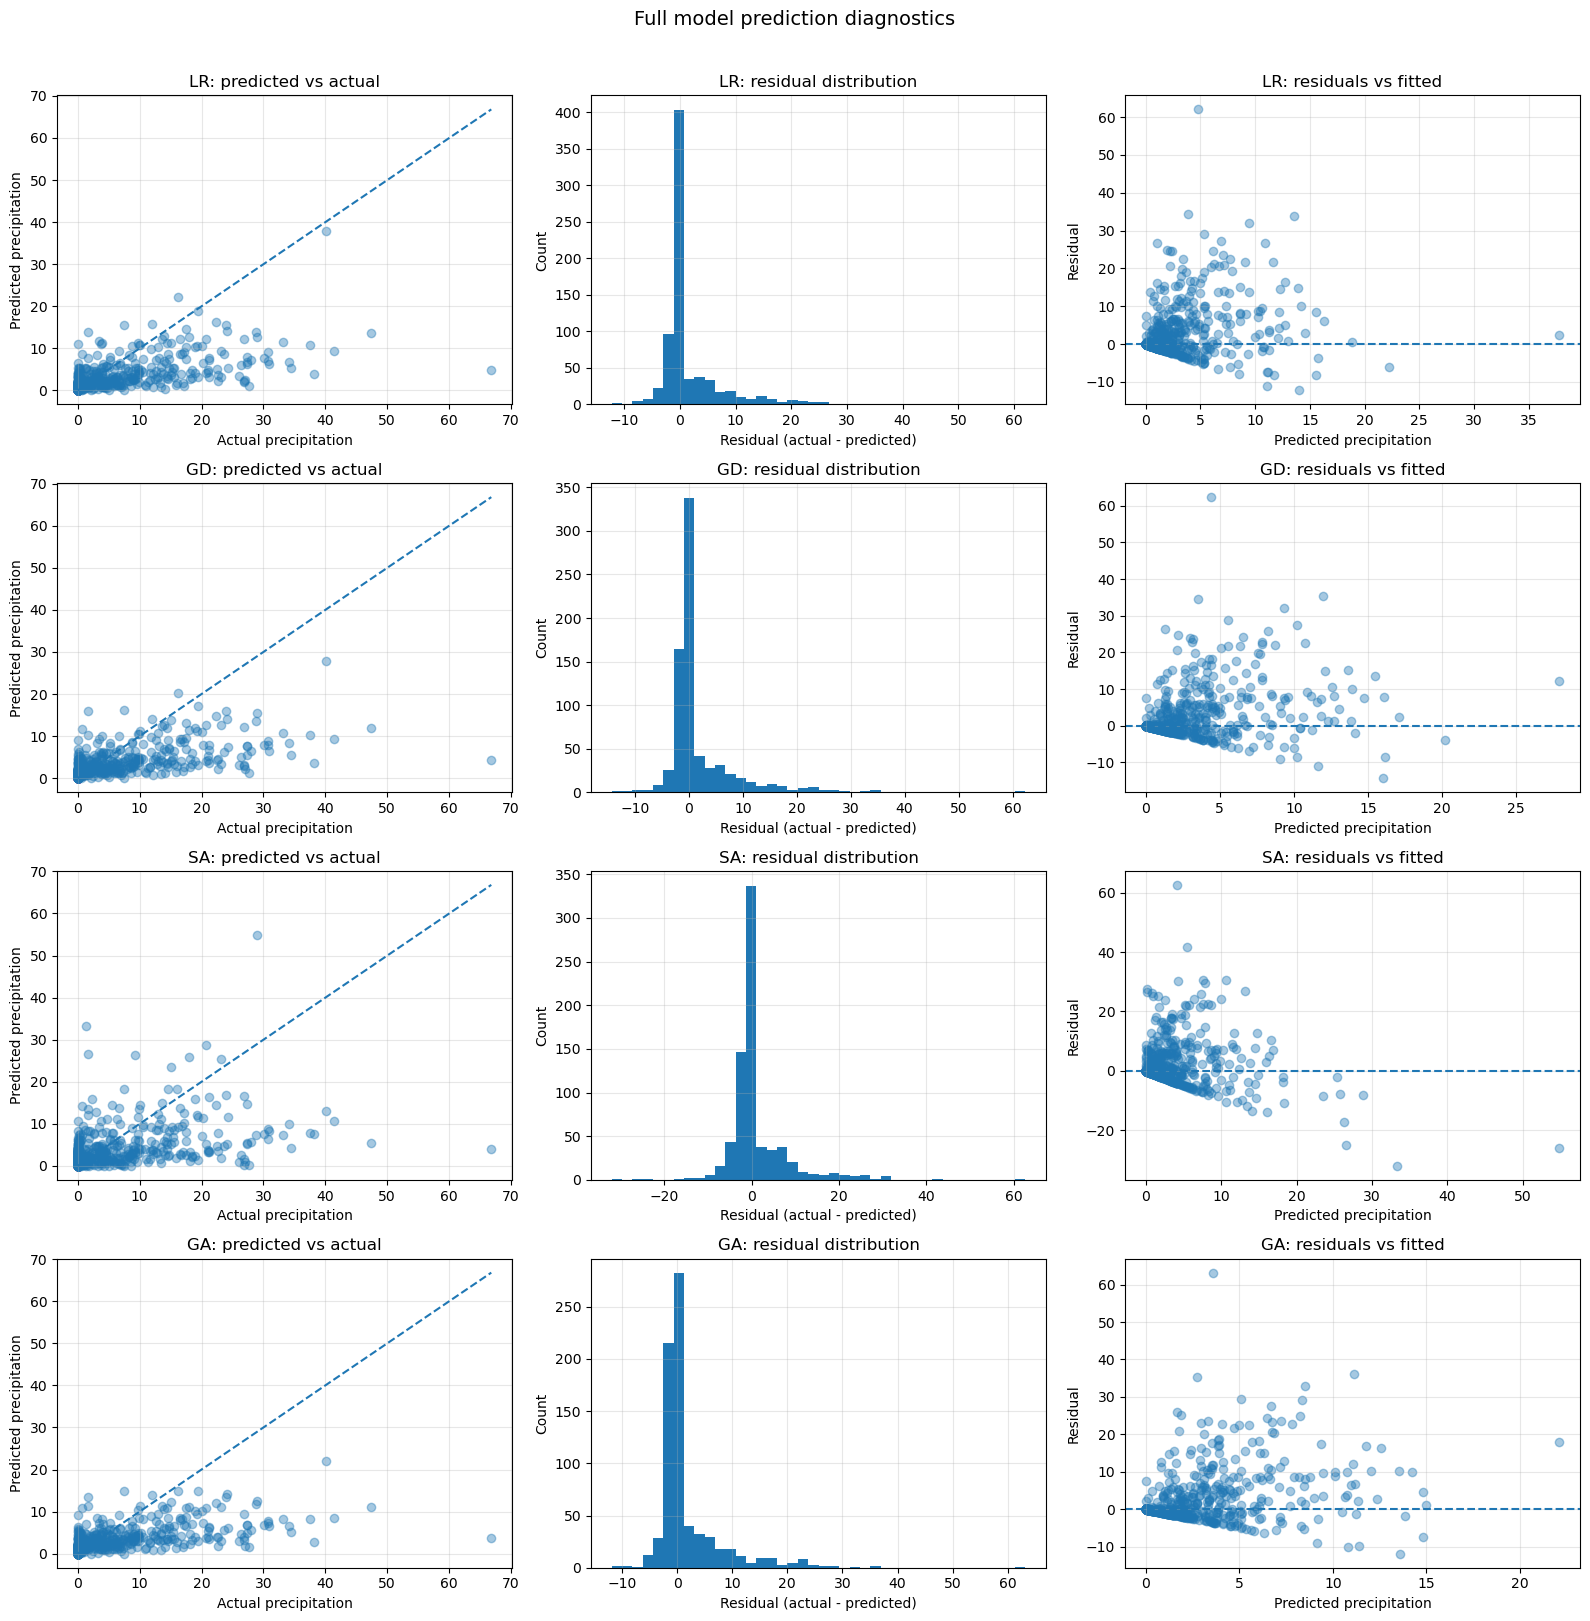

In [38]:
plot_diagnostics_grid(
    eval_dict=subset_eval,
    y_true=y_test,
    methods=["LR", "GD", "SA", "GA"],
    title_prefix="Subset model"
)

plot_diagnostics_grid(
    eval_dict=full_eval,
    y_true=y_test,
    methods=["LR", "GD", "SA", "GA"],
    title_prefix="Full model"
)


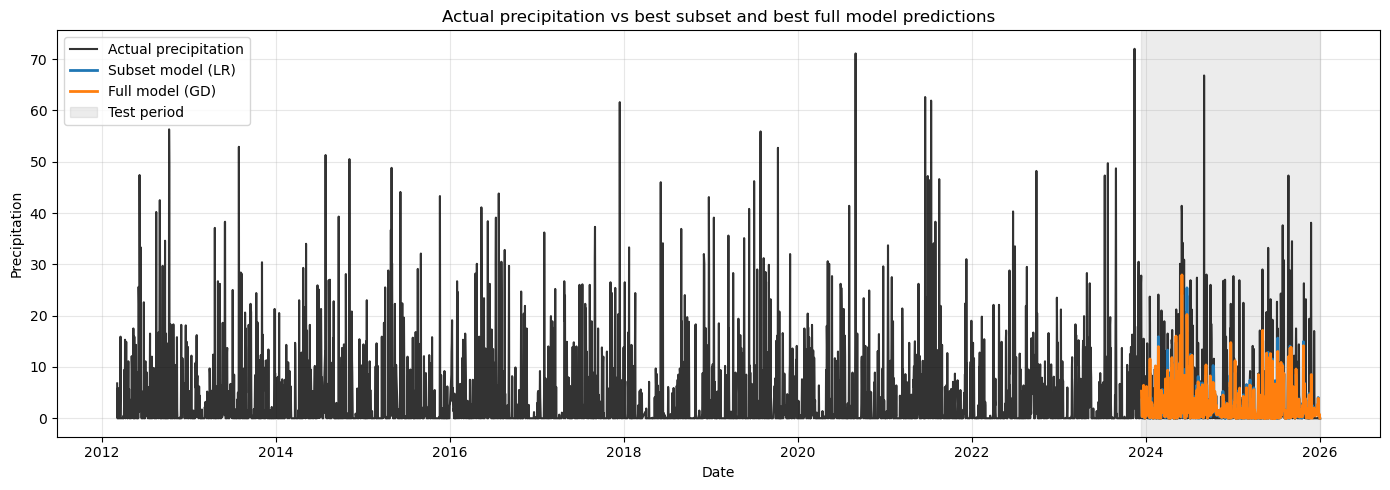

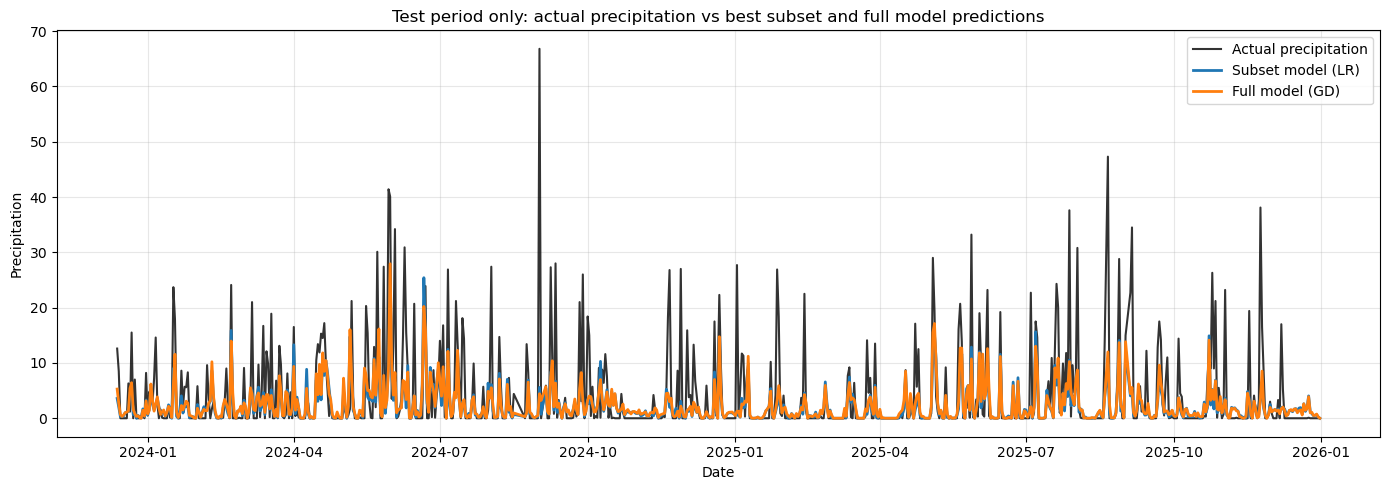

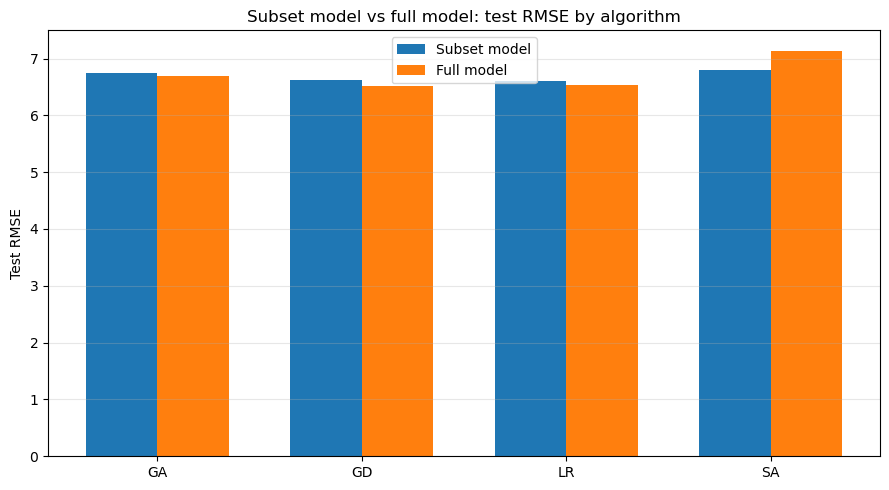

In [39]:
# Time-series comparison of the best subset model vs the best full model

subset_best_model = subset_eval["results_df"].iloc[0]["method"]
full_best_model = full_eval["results_df"].iloc[0]["method"]

used_df = get_used_split_frame(
    df=df,
    feature_cols=CANDIDATE_FEATURES,
    target_col=TARGET_COL,
    station_col=STATION_COL,
    date_col=DATE_COL,
)

n_test = len(y_test)
test_start_idx = len(used_df) - n_test
test_dates = used_df.iloc[test_start_idx:][DATE_COL].to_numpy()

actual_full_series = used_df[TARGET_COL].to_numpy()
actual_dates = used_df[DATE_COL].to_numpy()
actual_test_series = actual_full_series[test_start_idx:]

subset_pred_full = np.full(len(used_df), np.nan)
full_pred_full = np.full(len(used_df), np.nan)
subset_pred_full[test_start_idx:] = subset_eval["preds"][subset_best_model]
full_pred_full[test_start_idx:] = full_eval["preds"][full_best_model]

plt.figure(figsize=(14, 5))
plt.plot(actual_dates, actual_full_series, label="Actual precipitation", color="black", linewidth=1.5, alpha=0.8)
plt.plot(actual_dates, subset_pred_full, label=f"Subset model ({subset_best_model})", linewidth=2)
plt.plot(actual_dates, full_pred_full, label=f"Full model ({full_best_model})", linewidth=2)
plt.axvspan(test_dates[0], test_dates[-1], color="grey", alpha=0.15, label="Test period")
plt.xlabel("Date")
plt.ylabel("Precipitation")
plt.title("Actual precipitation vs best subset and best full model predictions")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(test_dates, actual_test_series, label="Actual precipitation", color="black", linewidth=1.5, alpha=0.8)
plt.plot(test_dates, subset_eval["preds"][subset_best_model], label=f"Subset model ({subset_best_model})", linewidth=2)
plt.plot(test_dates, full_eval["preds"][full_best_model], label=f"Full model ({full_best_model})", linewidth=2)
plt.xlabel("Date")
plt.ylabel("Precipitation")
plt.title("Test period only: actual precipitation vs best subset and full model predictions")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# Metric comparison plot: subset model vs full model for each algorithm

comp_plot = comparison.copy()
comp_plot = comp_plot.sort_values("method").reset_index(drop=True)
x = np.arange(len(comp_plot))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width / 2, comp_plot["test_rmse"], width=width, label="Subset model")
plt.bar(x + width / 2, comp_plot["rmse_full"], width=width, label="Full model")
plt.xticks(x, comp_plot["method"])
plt.ylabel("Test RMSE")
plt.title("Subset model vs full model: test RMSE by algorithm")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Generally all algorithms except SA benefitted from a full model and achieved slightly better fitting results.

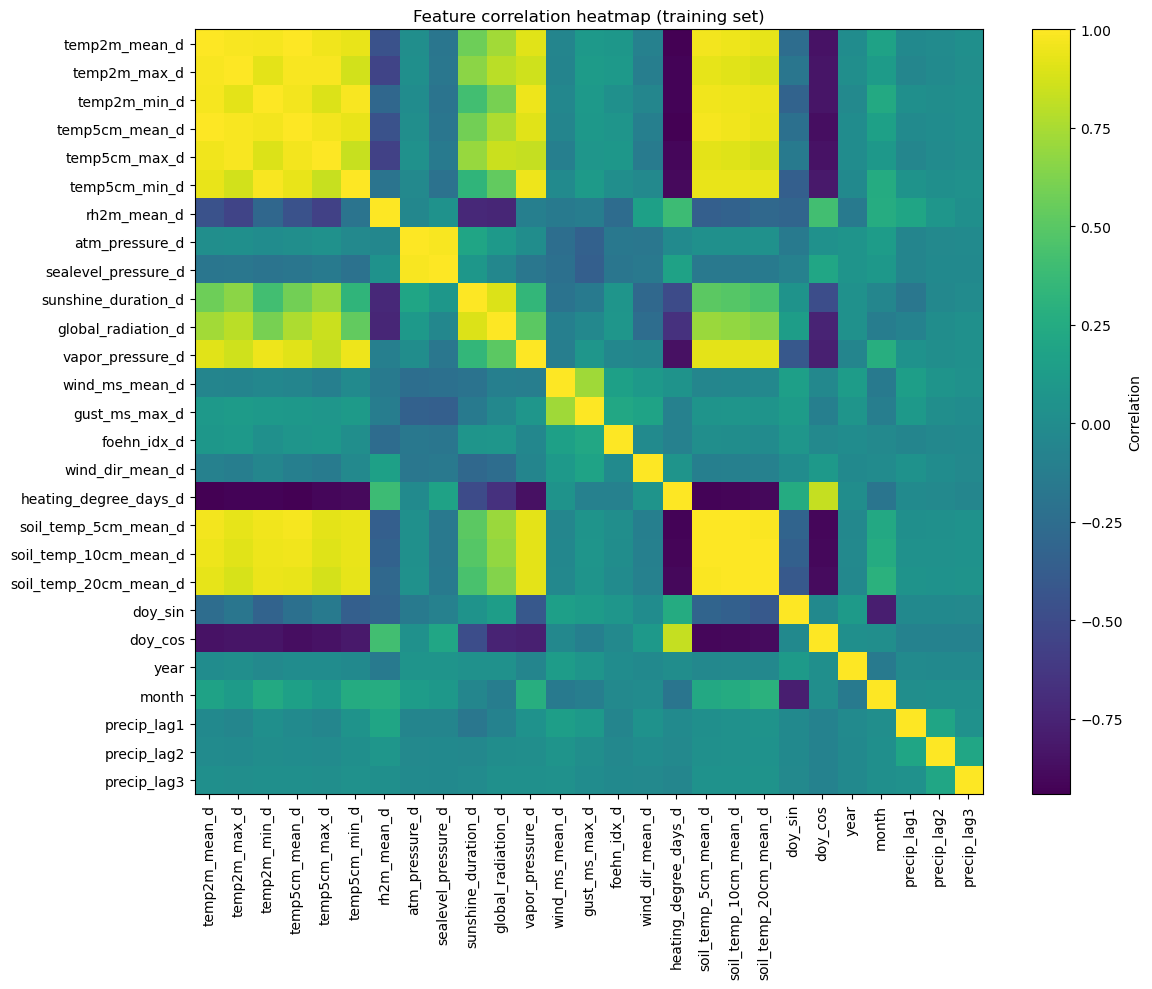

In [40]:
corr_df = pd.DataFrame(X_train, columns=CANDIDATE_FEATURES)
corr = corr_df.corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(CANDIDATE_FEATURES)), CANDIDATE_FEATURES, rotation=90)
plt.yticks(range(len(CANDIDATE_FEATURES)), CANDIDATE_FEATURES)
plt.title("Feature correlation heatmap (training set)")
plt.tight_layout()
plt.show()

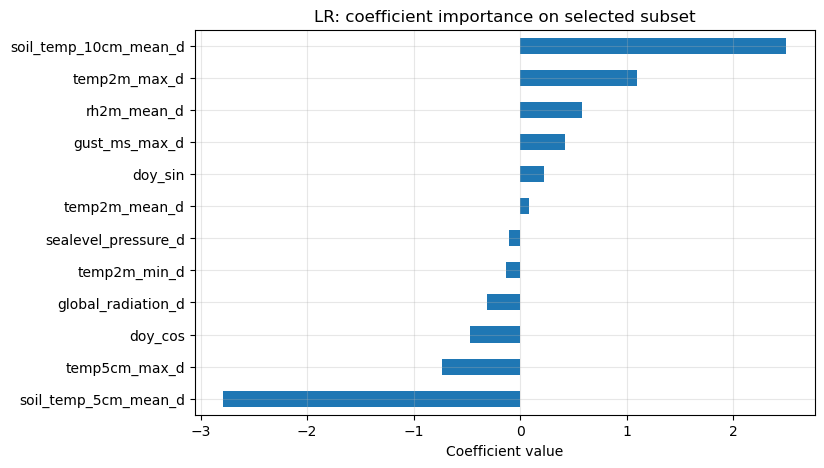

In [41]:
if subset_best_model == "LR":
    coef_values = subset_eval["weights"]["LR"]
else:
    coef_values = subset_eval["weights"][subset_best_model][1:]  # drop bias

coef_series = pd.Series(coef_values, index=best_subset)
coef_series = coef_series.reindex(coef_series.abs().sort_values(ascending=False).index)

plt.figure(figsize=(8, 5))
coef_series.iloc[:12].sort_values().plot(kind="barh")
plt.xlabel("Coefficient value")
plt.title(f"{subset_best_model}: coefficient importance on selected subset")
plt.grid(alpha=0.3)
plt.show()


### True forecasting approach

This part of the project was not done before the presentation. However, we thought it would be interesting to see how the algorithms would perform in a true forecasting problem. For each day $t$ precipitation is predicted from all numeric features observed in days $t-1$ to $t-6$. Again we use a chronological train/test split (70/30), train each algorithm once with the hyperparameters that were chosen in the grid search before and evaluate on the test set. Doing a separate hyperparameter search would make sense and could improve the results. 

C:\Users\Kai\AppData\Local\Temp\ipykernel_34780\150830511.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  wdf[f"{feat}_lag{L}"] = wdf[feat].shift(L)


Station used: WAE
Train rows: 3328, Test rows: 1427
Lag-window features: 150 (= 25 variables x 6 lags)


,method,rmse_forecast,mae_forecast,r2_forecast,runtime_sec
0,LR,7.400201,3.676111,0.035163,0.017003
1,GD,7.454058,3.638804,0.021068,6.598280
2,GA,7.797064,3.639861,-0.071098,5.099663
3,SA,8.352780,4.288095,-0.229219,2.302258


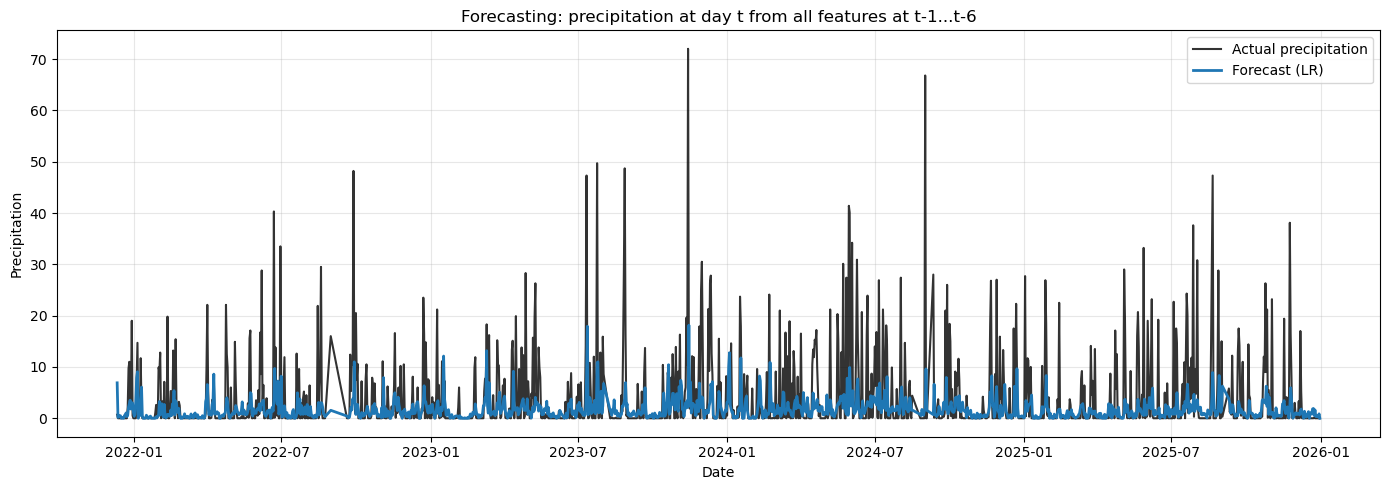

In [44]:
# -----------------------------
# 1) Build lag-window dataset
# -----------------------------
LAGS = [1, 2, 3, 4, 5, 6]

wdf = df.copy()
wdf[DATE_COL] = pd.to_datetime(wdf[DATE_COL])
wdf = wdf.sort_values([STATION_COL, DATE_COL]).reset_index(drop=True)

# Use one station for clean 1D time-series forecasting demo
if wdf[STATION_COL].nunique() > 1:
    station_use = wdf[STATION_COL].value_counts().idxmax()
    wdf = wdf[wdf[STATION_COL] == station_use].copy()
else:
    station_use = wdf[STATION_COL].iloc[0]

# Numeric base features (exclude identifiers/target/date)
exclude_cols = {TARGET_COL, STATION_COL}
if DATE_COL is not None:
    exclude_cols.add(DATE_COL)

base_feats = [
    c for c in wdf.columns
    if (c not in exclude_cols) and pd.api.types.is_numeric_dtype(wdf[c])
]

# Optional: avoid doubling old precip_lag* columns if already present
base_feats = [c for c in base_feats if not c.startswith("precip_lag")]

# Add past target explicitly
lag_source_feats = base_feats + [TARGET_COL]

for feat in lag_source_feats:
    for L in LAGS:
        wdf[f"{feat}_lag{L}"] = wdf[feat].shift(L)

lag_feature_cols = [f"{feat}_lag{L}" for feat in lag_source_feats for L in LAGS]

model_df = (
    wdf[[DATE_COL, TARGET_COL] + lag_feature_cols]
    .dropna()
    .sort_values(DATE_COL)
    .reset_index(drop=True)
)

# -----------------------------
# 2) Chronological split
# -----------------------------
n = len(model_df)
n_train = int(np.floor(0.70 * n))
train_df = model_df.iloc[:n_train].copy()
test_df  = model_df.iloc[n_train:].copy()

X_train = train_df[lag_feature_cols].to_numpy(dtype=float)
y_train = train_df[TARGET_COL].to_numpy(dtype=float)
X_test  = test_df[lag_feature_cols].to_numpy(dtype=float)
y_test  = test_df[TARGET_COL].to_numpy(dtype=float)
test_dates = test_df[DATE_COL].to_numpy()

# Scale from training only
scaler_f = StandardScaler()
X_train_s = scaler_f.fit_transform(X_train)
X_test_s = scaler_f.transform(X_test)

# Target transform for optimization
y_train_model = transform_target(y_train)

# -----------------------------
# 3) Reuse best configs (fallbacks included)
# -----------------------------
gd_cfg = (
    best_cfg_by_method_full["GD"] if "best_cfg_by_method_full" in globals() and "GD" in best_cfg_by_method_full
    else best_cfg_by_method["GD"] if "best_cfg_by_method" in globals() and "GD" in best_cfg_by_method
    else GDConfig(lr=0.05, steps=5000, l2=0.0, tol=1e-8)
)

sa_base = (
    best_cfg_by_method_full["SA"] if "best_cfg_by_method_full" in globals() and "SA" in best_cfg_by_method_full
    else best_cfg_by_method["SA"] if "best_cfg_by_method" in globals() and "SA" in best_cfg_by_method
    else SAConfig(steps=5000, T0=1.0, alpha=0.997, step_sigma=0.05, l2=0.0, seed=RANDOM_SEED)
)

ga_base = (
    best_cfg_by_method_full["GA"] if "best_cfg_by_method_full" in globals() and "GA" in best_cfg_by_method_full
    else best_cfg_by_method["GA"] if "best_cfg_by_method" in globals() and "GA" in best_cfg_by_method
    else GAConfig(pop_size=100, generations=200, elite=6, tournament_k=3,
                  crossover_rate=0.9, mutation_rate=0.3, mutation_sigma=0.1,
                  init_sigma=0.1, l2=0.0, seed=RANDOM_SEED)
)

# Fix stochastic seeds for reproducibility
sa_cfg = SAConfig(
    steps=sa_base.steps, T0=sa_base.T0, alpha=sa_base.alpha,
    step_sigma=sa_base.step_sigma, l2=sa_base.l2, seed=RANDOM_SEED
)
ga_cfg = GAConfig(
    pop_size=ga_base.pop_size, generations=ga_base.generations, elite=ga_base.elite,
    tournament_k=ga_base.tournament_k, crossover_rate=ga_base.crossover_rate,
    mutation_rate=ga_base.mutation_rate, mutation_sigma=ga_base.mutation_sigma,
    init_sigma=ga_base.init_sigma, l2=ga_base.l2, seed=RANDOM_SEED
)

# -----------------------------
# 4) Train + predict with all methods
# -----------------------------
forecast_eval = {"preds": {}, "runtime_sec": {}, "metrics": {}}

# LR
t0 = time.time()
lr = LinearRegression()
lr.fit(X_train_s, y_train_model)
forecast_eval["runtime_sec"]["LR"] = time.time() - t0
forecast_eval["preds"]["LR"] = prediction_to_original_scale(lr.predict(X_test_s))

# GD
t0 = time.time()
w_gd, _ = fit_gd(X_train_s, y_train_model, gd_cfg)
forecast_eval["runtime_sec"]["GD"] = time.time() - t0
forecast_eval["preds"]["GD"] = prediction_to_original_scale(add_bias(X_test_s) @ w_gd)

# SA
t0 = time.time()
w_sa, _ = fit_sa(X_train_s, y_train_model, sa_cfg)
forecast_eval["runtime_sec"]["SA"] = time.time() - t0
forecast_eval["preds"]["SA"] = prediction_to_original_scale(add_bias(X_test_s) @ w_sa)

# GA
t0 = time.time()
w_ga, _ = fit_ga(X_train_s, y_train_model, ga_cfg)
forecast_eval["runtime_sec"]["GA"] = time.time() - t0
forecast_eval["preds"]["GA"] = prediction_to_original_scale(add_bias(X_test_s) @ w_ga)

# Metrics
for method, pred in forecast_eval["preds"].items():
    forecast_eval["metrics"][method] = {
        "rmse_forecast": float(np.sqrt(mean_squared_error(y_test, pred))),
        "mae_forecast": float(mean_absolute_error(y_test, pred)),
        "r2_forecast": float(r2_score(y_test, pred)),
        "runtime_sec": float(forecast_eval["runtime_sec"][method]),
    }

forecast_results = (
    pd.DataFrame(forecast_eval["metrics"])
    .T
    .reset_index()
    .rename(columns={"index": "method"})
    .sort_values("rmse_forecast")
    .reset_index(drop=True)
)

print(f"Station used: {station_use}")
print(f"Train rows: {len(train_df)}, Test rows: {len(test_df)}")
print(f"Lag-window features: {len(lag_feature_cols)} (= {len(lag_source_feats)} variables x {len(LAGS)} lags)")
display(forecast_results)

# -----------------------------
# 5) Plot best forecast
# -----------------------------
best_method = forecast_results.iloc[0]["method"]

plt.figure(figsize=(14, 5))
plt.plot(test_dates, y_test, label="Actual precipitation", color="black", linewidth=1.5, alpha=0.8)
plt.plot(test_dates, forecast_eval["preds"][best_method], label=f"Forecast ({best_method})", linewidth=2)
plt.xlabel("Date")
plt.ylabel("Precipitation")
plt.title("Forecasting: precipitation at day t from all features at t-1...t-6")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Interestingly, the models achieve only a slightly worse score compared to the fitting problem. Again we can observe similar behaviors: GD and LR perform almost identically well, followed by GA. Again, SA was the worst performing algorithm. 